# 2026-08-03 Initial Check: post-peak rSFMS

This notebook shows only the resolved star-forming main sequence (rSFMS) for
**post-peak galaxies** (infall class 1 from `mauve_master_wiki_newclass.fits`).
MAUVE spaxels and summary trends use distinct blue-adjacent colours for visibility. The comparison
includes the Pessa et al. (2021) 100 pc rSFMS fit and one pooled MAUVE
trend: the mean in log Σ_SFR.


## Setup

The analysis discovers current products below `v3tk_v7.6.8`, keeps only
post-peak galaxies, and uses finite star-forming (SF) SFR and stellar-mass
pixels without additional EW(Hα) or Hα-dispersion cuts. `NGC4567_8`
inherits class 3 only when both component
galaxies have the same infall class.


In [1]:
# Current further-project products used by the post-peak rSFMS analysis.
from __future__ import annotations

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
RUN_LABEL = "v3tk_v7.6.8"
RUN_DIR = PROJECT_ROOT / RUN_LABEL
OUTDIR = PROJECT_ROOT / "quicklook_figures_further"

plt.style.use("default")
mpl.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.grid": False,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Current further run directory: {RUN_DIR}")
print("Active save paths are intentionally commented out in this notebook.")


Project root: /Users/Igniz/Desktop/ICRAR/further
Current further run directory: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8
Active save paths are intentionally commented out in this notebook.


In [2]:
def first_existing(*paths: Path | None) -> Path | None:
    for path in paths:
        if path is not None and path.exists():
            return path
    return None


def fits_has_hdus(path: Path | None, names: list[str]) -> bool:
    if path is None or not Path(path).exists():
        return False
    try:
        with fits.open(path, memmap=True) as hdul:
            hdu_names = {h.name.upper() for h in hdul}
        return all(name.upper() in hdu_names for name in names)
    except Exception:
        return False


def align_map_to_shape(map_data, target_shape, *, label="map", fill_value=np.nan, max_delta=2):
    """Align a nearly matching 2D map to target_shape by copying the overlap."""
    target_shape = tuple(target_shape)
    arr = np.asarray(map_data, dtype=float)
    if arr.shape == target_shape:
        return arr
    if arr.ndim != len(target_shape):
        raise ValueError(f"{label}: cannot align ndim {arr.ndim} to target shape {target_shape}")

    deltas = tuple(abs(src - dst) for src, dst in zip(arr.shape, target_shape))
    if any(delta > max_delta for delta in deltas):
        raise ValueError(f"{label}: shape {arr.shape} differs too much from target {target_shape}")

    aligned = np.full(target_shape, fill_value, dtype=float)
    overlap = tuple(min(src, dst) for src, dst in zip(arr.shape, target_shape))
    slices = tuple(slice(0, n) for n in overlap)
    aligned[slices] = arr[slices]
    print(f"  {label}: aligned shape {arr.shape} -> {target_shape}; overlap={overlap}")
    return aligned


def discover_further_products(run_dir: Path = RUN_DIR) -> pd.DataFrame:
    rows = []
    if not run_dir.exists():
        raise FileNotFoundError(f"Missing run directory: {run_dir}")

    for gal_dir in sorted(
        p for p in run_dir.iterdir()
        if p.is_dir() and not p.name.endswith("_logs")
    ):
        gal = gal_dir.name
        spatial_raw = gal_dir / f"{gal}_spatial_binning_maps.fits"
        spatial_further = gal_dir / f"{gal}_spatial_binning_maps_further.fits"
        gas_raw_lower = gal_dir / f"{gal}_gas_bin_maps.fits"
        gas_raw_upper = gal_dir / f"{gal}_gas_BIN_maps.fits"
        gas_further_lower = gal_dir / f"{gal}_gas_bin_maps_further.fits"
        gas_further_upper = gal_dir / f"{gal}_gas_BIN_maps_further.fits"
        sfh = gal_dir / f"{gal}_sfh_maps.fits"
        sfh_weights = gal_dir / f"{gal}_sfh_weights.fits"
        kin = gal_dir / f"{gal}_kin_maps.fits"
        gas_spaxel = gal_dir / f"{gal}_gas_spaxel_maps.fits"
        mask = gal_dir / f"{gal}_mask.fits"

        spatial_preferred = first_existing(spatial_further, spatial_raw)
        gas_preferred = first_existing(gas_further_lower, gas_further_upper, gas_raw_lower, gas_raw_upper)

        rows.append({
            "galaxy": gal,
            "folder": gal_dir,
            "spatial_path": spatial_preferred,
            "gas_path": gas_preferred,
            "ew_path": first_existing(gal_dir / f"{gal}_proxy_EW_maps_further.fits", gal_dir / f"{gal}_proxy_EW_maps.fits"),
            "sfh_path": sfh if sfh.exists() else None,
            "sfh_weights_path": sfh_weights if sfh_weights.exists() else None,
            "kin_path": kin if kin.exists() else None,
            "gas_spaxel_path": gas_spaxel if gas_spaxel.exists() else None,
            "mask_path": mask if mask.exists() else None,
            "sfr_log_path": first_existing(RUN_DIR / "sfr_logs" / f"{gal}.log"),
            "mass_log_path": first_existing(RUN_DIR / "mass_logs" / f"{gal}.log"),
            "source": "further",
            "has_spatial": spatial_preferred is not None,
            "has_gas": gas_preferred is not None,
            "has_sfh": sfh.exists(),
            "has_sfh_weights": sfh_weights.exists(),
            "has_kin": kin.exists(),
            "has_gas_spaxel": gas_spaxel.exists(),
            "has_mask": mask.exists(),
            "has_spatial_further": spatial_further.exists(),
            "has_gas_further": gas_further_lower.exists() or gas_further_upper.exists(),
        })

    table = pd.DataFrame(rows).set_index("galaxy", drop=False)
    if table.empty:
        raise RuntimeError(f"No galaxy folders found below {run_dir}")

    table["has_mass_map"] = [fits_has_hdus(path, ["LOGMASS_SURFACE_DENSITY"]) for path in table["spatial_path"]]
    table["has_sfr_map"] = [fits_has_hdus(path, ["LOGSFR_SURFACE_DENSITY_SF"]) for path in table["gas_path"]]
    table["has_o3n2_m13"] = [fits_has_hdus(path, ["O_H_O3N2_M13_HII", "O_H_O3N2_M13_SF"]) for path in table["gas_path"]]
    table["has_proxy_ew"] = table["ew_path"].notna()
    table["ready_physics_maps"] = table["has_mass_map"] & table["has_sfr_map"] & table["has_o3n2_m13"]
    table["ready_raw_gas_qc"] = table["has_spatial"] & table["has_gas"]
    table["ready_sfh_qc"] = table["has_spatial"] & table["has_sfh"]
    return table



CURRENT_PRODUCTS = discover_further_products()

CURRENT_READY_PHYSICS_GALAXIES = CURRENT_PRODUCTS.index[CURRENT_PRODUCTS["ready_physics_maps"]].tolist()
CURRENT_NOT_PHYSICS_READY = CURRENT_PRODUCTS.index[~CURRENT_PRODUCTS["ready_physics_maps"]].tolist()

FAKE_GALAXIES = []
UNREUSABLE_MISSING_GALAXIES = CURRENT_NOT_PHYSICS_READY

PRODUCTS = CURRENT_PRODUCTS.copy()
PRODUCTS["source"] = "further_ready"
PRODUCTS.loc[~PRODUCTS["ready_physics_maps"], "source"] = "further_not_science_ready"
PRODUCTS["fake_reason"] = ""
PRODUCTS.loc[UNREUSABLE_MISSING_GALAXIES, "fake_reason"] = "kept for inventory/QC only; not science-ready in current further products"

ANALYSIS_GALAXIES = CURRENT_READY_PHYSICS_GALAXIES
QC_GALAXIES = PRODUCTS.index[PRODUCTS["ready_raw_gas_qc"]].tolist()
SFH_QC_GALAXIES = PRODUCTS.index[PRODUCTS["ready_sfh_qc"]].tolist()
DISPLAY_COLUMNS = [
    "source",
    "has_spatial",
    "has_gas",
    "has_mass_map",
    "has_sfr_map",
    "has_o3n2_m13",
    "has_proxy_ew",
    "has_sfh",
    "has_sfh_weights",
    "has_kin",
    "has_gas_spaxel",
    "has_mask",
    "spatial_path",
    "gas_path",
    "ew_path",
    "sfr_log_path",
    "mass_log_path",
    "fake_reason",
]

print(f"Discovered current galaxy folders: {len(CURRENT_PRODUCTS)}")
print(f"Science-ready current further galaxies: {len(CURRENT_READY_PHYSICS_GALAXIES)}")
print(f"Not science-ready current further galaxies: {len(CURRENT_NOT_PHYSICS_READY)}")
print("Extended fallback galaxies: 0 (disabled; using current further products only)")
print("Analysis galaxies:", ", ".join(ANALYSIS_GALAXIES))
print("Current not-science-ready galaxies:", ", ".join(UNREUSABLE_MISSING_GALAXIES) if UNREUSABLE_MISSING_GALAXIES else "none")
display(PRODUCTS[DISPLAY_COLUMNS])

def further_spatial_path(galaxy: str) -> Path:
    path = PRODUCTS.loc[galaxy, "spatial_path"]
    if path is None:
        raise FileNotFoundError(f"No spatial product registered for {galaxy}")
    return Path(path)


def further_gas_path(galaxy: str) -> Path:
    path = PRODUCTS.loc[galaxy, "gas_path"]
    if path is None:
        raise FileNotFoundError(f"No gas product registered for {galaxy}")
    return Path(path)


def further_ew_path(galaxy: str, suffix: str | None = None) -> Path:
    if galaxy in PRODUCTS.index and PRODUCTS.loc[galaxy, "ew_path"] is not None:
        return Path(PRODUCTS.loc[galaxy, "ew_path"])

    suffixes = []
    if suffix:
        suffixes.append(suffix)
    suffixes.extend(["_proxy_EW_maps.fits", "_proxy_EW_maps_further.fits", "_pseudo_EW_maps.fits"])
    candidates = []
    for suffix_item in dict.fromkeys(suffixes):
        candidates.append(RUN_DIR / galaxy / f"{galaxy}{suffix_item}")
        candidates.append(PROJECT_ROOT / f"{galaxy}{suffix_item}")
    found = first_existing(*candidates)
    if found is None:
        checked = "\n".join(f"  - {path}" for path in candidates)
        raise FileNotFoundError(f"No EW product found for {galaxy}. Checked:\n{checked}")
    return found


def sfr_log_path(galaxy: str) -> Path | None:
    if galaxy in PRODUCTS.index:
        path = PRODUCTS.loc[galaxy, "sfr_log_path"]
        return None if path is None else Path(path)
    return first_existing(RUN_DIR / "sfr_logs" / f"{galaxy}.log")


def mass_log_path(galaxy: str) -> Path | None:
    if galaxy in PRODUCTS.index:
        path = PRODUCTS.loc[galaxy, "mass_log_path"]
        return None if path is None else Path(path)
    return first_existing(RUN_DIR / "mass_logs" / f"{galaxy}.log")


def physics_ready_galaxies(require_ew: bool = True) -> list[str]:
    galaxies = PRODUCTS.index[PRODUCTS["ready_physics_maps"]].tolist()
    if require_ew:
        galaxies = [gal for gal in galaxies if PRODUCTS.loc[gal, "has_proxy_ew"]]
    return galaxies


def old_paper_cells_ready(require_ew: bool = True) -> bool:
    return len(physics_ready_galaxies(require_ew=require_ew)) > 0


COMBINED_GALAXY_COMPONENTS = {
    "NGC4567_8": ("NGC4567", "NGC4568"),
}


def add_combined_infall_classes(infall_classes: dict[str, int]) -> dict[str, int]:
    """Assign a combined product only when all components share one stage."""
    resolved = dict(infall_classes)
    for combined_id, components in COMBINED_GALAXY_COMPONENTS.items():
        missing = [component for component in components if component not in resolved]
        if missing:
            raise KeyError(
                f"Cannot classify {combined_id}: missing components {', '.join(missing)}"
            )
        component_stages = {resolved[component] for component in components}
        if len(component_stages) != 1:
            details = ", ".join(
                f"{component}=stage {resolved[component]}" for component in components
            )
            raise ValueError(f"Cannot classify {combined_id}: {details}")
        resolved[combined_id] = component_stages.pop()
    return resolved




Discovered current galaxy folders: 32
Science-ready current further galaxies: 32
Not science-ready current further galaxies: 0
Extended fallback galaxies: 0 (disabled; using current further products only)
Analysis galaxies: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4321, NGC4330, NGC4351, NGC4380, NGC4383, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4535, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698
Current not-science-ready galaxies: none


,source,has_spatial,has_gas,has_mass_map,has_sfr_map,has_o3n2_m13,has_proxy_ew,has_sfh,has_sfh_weights,has_kin,has_gas_spaxel,has_mask,spatial_path,gas_path,ew_path,sfr_log_path,mass_log_path,fake_reason
galaxy,,,,,,,,,,,,,,,,,,
IC3392,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4064,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4189,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4192,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4254,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4293,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4294,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4298,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4302,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,


In [3]:
import matplotlib as mpl

# Increase tick label font sizes and tick length/width globally for all plots
mpl.rcParams.update({
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})


Finite full-sample SF spaxels: 4,046,661


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_39827/1504140264.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.85])


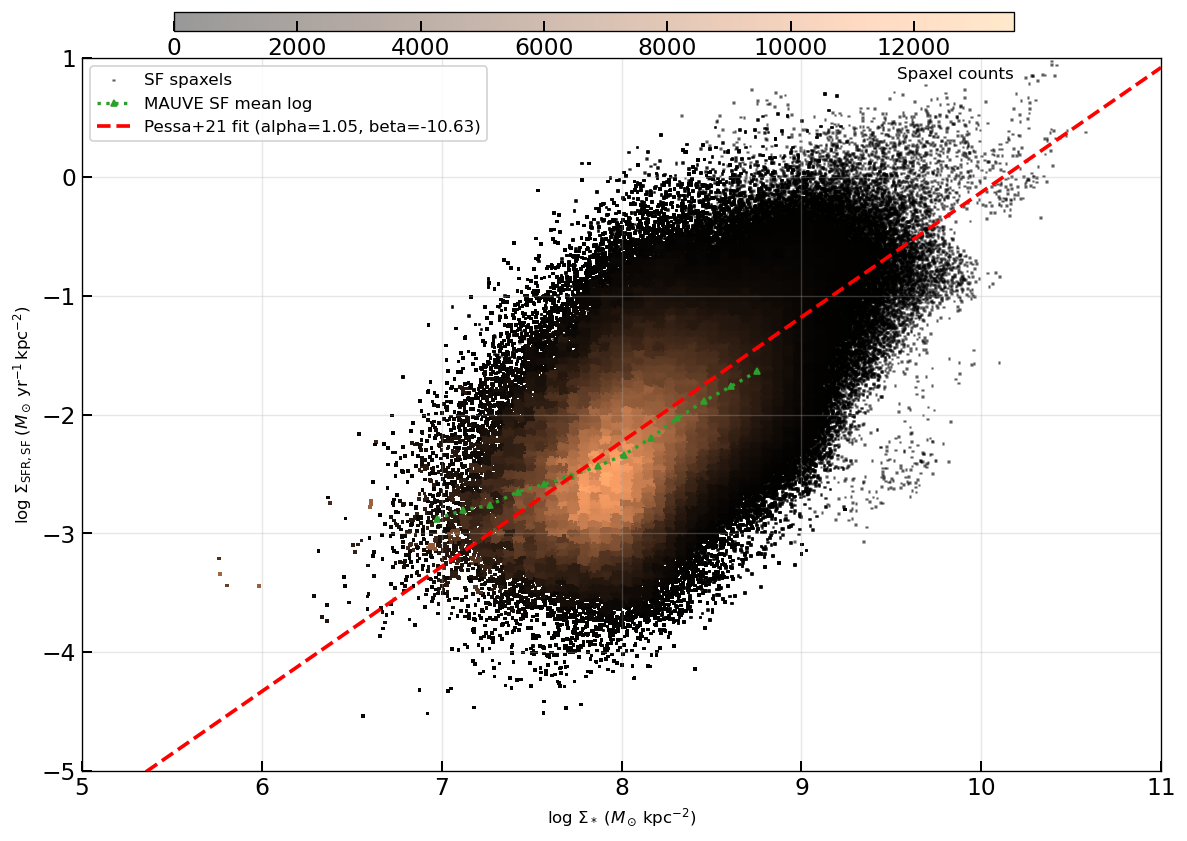

In [4]:
# ------------------------------------------------------------------
# COMBINED PLOT - rSFMS using all finite SF spaxels
# Current full further sample, independent of infall stage
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

def load_selected_rsfms_maps(galaxy):
    """Load and align the stellar-mass and SF SFR maps."""
    spatial_path = further_spatial_path(galaxy)
    gas_path = further_gas_path(galaxy)

    with fits.open(spatial_path) as hdul:
        log_sigma_m = np.asarray(
            hdul["LOGMASS_SURFACE_DENSITY"].data, dtype=float
        )
    with fits.open(gas_path) as hdul:
        log_sigma_sfr = np.asarray(
            hdul["LOGSFR_SURFACE_DENSITY_SF"].data, dtype=float
        )

    target_shape = log_sigma_sfr.shape
    log_sigma_m = align_map_to_shape(
        log_sigma_m, target_shape, label=f"{galaxy} stellar mass"
    )
    return log_sigma_m, log_sigma_sfr


def selected_rsfms_mask(log_sigma_m, log_sigma_sfr):
    """Keep finite stellar-mass pixels from the SF-only SFR map."""
    return np.isfinite(log_sigma_m) & np.isfinite(log_sigma_sfr)


def binned_rsfms_mean_trend(x, y, *, bin_width, min_pixels):
    """Bin the central 95% in mass and preserve gaps between valid bins."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    trend_lo, trend_hi = np.nanpercentile(x, [2.5, 97.5])
    central = (x >= trend_lo) & (x <= trend_hi)
    x_data = x[central]
    y_data = y[central]

    edges = np.arange(trend_lo, trend_hi, bin_width)
    if edges.size == 0:
        edges = np.asarray([trend_lo])
    if edges[-1] < trend_hi:
        edges = np.append(edges, trend_hi)

    trend_x = []
    mean_log = []
    counts = []
    last_bin = len(edges) - 2
    for index, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
        if index == last_bin:
            in_bin = (x_data >= left) & (x_data <= right)
        else:
            in_bin = (x_data >= left) & (x_data < right)
        count = int(np.count_nonzero(in_bin))
        counts.append(count)
        if count < min_pixels:
            trend_x.append(0.5 * (left + right))
            mean_log.append(np.nan)
            continue

        x_bin = x_data[in_bin]
        y_bin = y_data[in_bin]
        trend_x.append(np.mean(x_bin))
        mean_log.append(np.mean(y_bin))

    return (
        np.asarray(trend_x),
        np.asarray(mean_log),
        np.asarray(counts, dtype=int),
        (trend_lo, trend_hi),
    )


# Discover every current further galaxy with mass and SF-SFR maps.
full_sample_galaxies = PRODUCTS.index[
    PRODUCTS["has_mass_map"]
    & PRODUCTS["has_sfr_map"]
].tolist()

all_x_full = []
all_y_full = []
full_sample_galaxy_counts = {}

for galaxy in full_sample_galaxies:
    maps = load_selected_rsfms_maps(galaxy)
    selected = selected_rsfms_mask(*maps)
    log_sigma_m, log_sigma_sfr = maps

    if np.any(selected):
        x_det = log_sigma_m[selected]
        y_det = log_sigma_sfr[selected]
        all_x_full.extend(x_det.ravel())
        all_y_full.extend(y_det.ravel())
        full_sample_galaxy_counts[galaxy] = int(x_det.size)
    else:
        full_sample_galaxy_counts[galaxy] = 0
        print(f"Skipping {galaxy}: no finite SF spaxels")

all_x_full = np.asarray(all_x_full, dtype=float)
all_y_full = np.asarray(all_y_full, dtype=float)
if all_x_full.size == 0:
    raise RuntimeError("No valid SF-spaxel rSFMS data found.")

print(
    "Finite full-sample SF spaxels: "
    f"{all_y_full.size:,}"
)

fig, ax_combined = plt.subplots(figsize=(10, 8))

# Density-colored scatter of all selected pixels.
H, xedges, yedges = np.histogram2d(
    all_x_full,
    all_y_full,
    bins=100,
    range=[[5, 11], [-5, 1]],
)
x_idx = np.clip(np.digitize(all_x_full, xedges) - 1, 0, H.shape[0] - 1)
y_idx = np.clip(np.digitize(all_y_full, yedges) - 1, 0, H.shape[1] - 1)
density = H[x_idx, y_idx]

scatter = ax_combined.scatter(
    all_x_full,
    all_y_full,
    c=density,
    s=1,
    alpha=0.4,
    marker=",",
    cmap="copper",
    label="SF spaxels",
    zorder=1,
)

# The mean-log trend uses exact percentile bounds. NaNs preserve gaps where a bin
# contains fewer than 50 selected pixels, preventing unsupported line segments.
(
    trend_x_full,
    mean_log_sf_full,
    trend_counts_full,
    (trend_lo_full, trend_hi_full),
) = binned_rsfms_mean_trend(
    all_x_full,
    all_y_full,
    bin_width=0.15,
    min_pixels=50,
)
bin_width = 0.15
min_pixels_per_bin = 50

ax_combined.plot(
    trend_x_full,
    mean_log_sf_full,
    color="tab:green",
    linestyle=":",
    marker="^",
    markersize=3.6,
    linewidth=2.0,
    label="MAUVE SF mean log",
    zorder=7,
)

pessa_alpha_full = 1.05
pessa_intercept_full = -10.63
x_pessa_full = np.linspace(5, 11, 200)
y_pessa_full = pessa_alpha_full * x_pessa_full + pessa_intercept_full
ax_combined.plot(
    x_pessa_full,
    y_pessa_full,
    color="red",
    linestyle="--",
    linewidth=2.2,
    label="Pessa+21 fit (alpha=1.05, beta=-10.63)",
    zorder=8,
)

ax_combined.set_xlabel(r"$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$")
ax_combined.set_ylabel(
    r"$\log\,\Sigma_{\mathrm{SFR,SF}}\; "
    r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
)
ax_combined.set_xlim(5, 11)
ax_combined.set_ylim(-5, 1)
ax_combined.grid(True, alpha=0.3)
ax_combined.legend(
    loc="upper left", ncol=1, frameon=True, framealpha=0.85
)

cbar_ax = fig.add_axes([0.15, 0.85, 0.7, 0.02])
cbar = plt.colorbar(scatter, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Spaxel counts", loc="right")
plt.tight_layout(rect=[0, 0, 1, 0.85])
# plt.savefig(OUTDIR / "rSFMS_combined_full_further.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "rSFMS_combined_full_further.pdf", bbox_inches="tight")
plt.show()


## Post-peak resolved star-forming main sequence

Pale cyan-blue points are the pooled post-peak SF spaxels. The summary
curve follows the detected-pixel definition in cell 25 of
`20260412_Plot_Paper_1_referee.ipynb`: the mean log Σ_SFR in 0.15 dex
stellar-mass bins. The red dashed curve is the
published Pessa et al. (2021) 100 pc fit.


  IC3392: 18,029 post-peak SF spaxels
  NGC4064: 13,702 post-peak SF spaxels
  NGC4293: 7,279 post-peak SF spaxels
  NGC4380: 110,006 post-peak SF spaxels
  NGC4394: 55,747 post-peak SF spaxels
  NGC4405: 18,245 post-peak SF spaxels
  NGC4419: 16,664 post-peak SF spaxels
  NGC4450: 33,964 post-peak SF spaxels
  NGC4457: 18,919 post-peak SF spaxels
  NGC4569: 86,774 post-peak SF spaxels
  NGC4580: 33,208 post-peak SF spaxels
  NGC4606: 3,564 post-peak SF spaxels
  NGC4607: 23,538 post-peak SF spaxels
  NGC4698: 27,903 post-peak SF spaxels


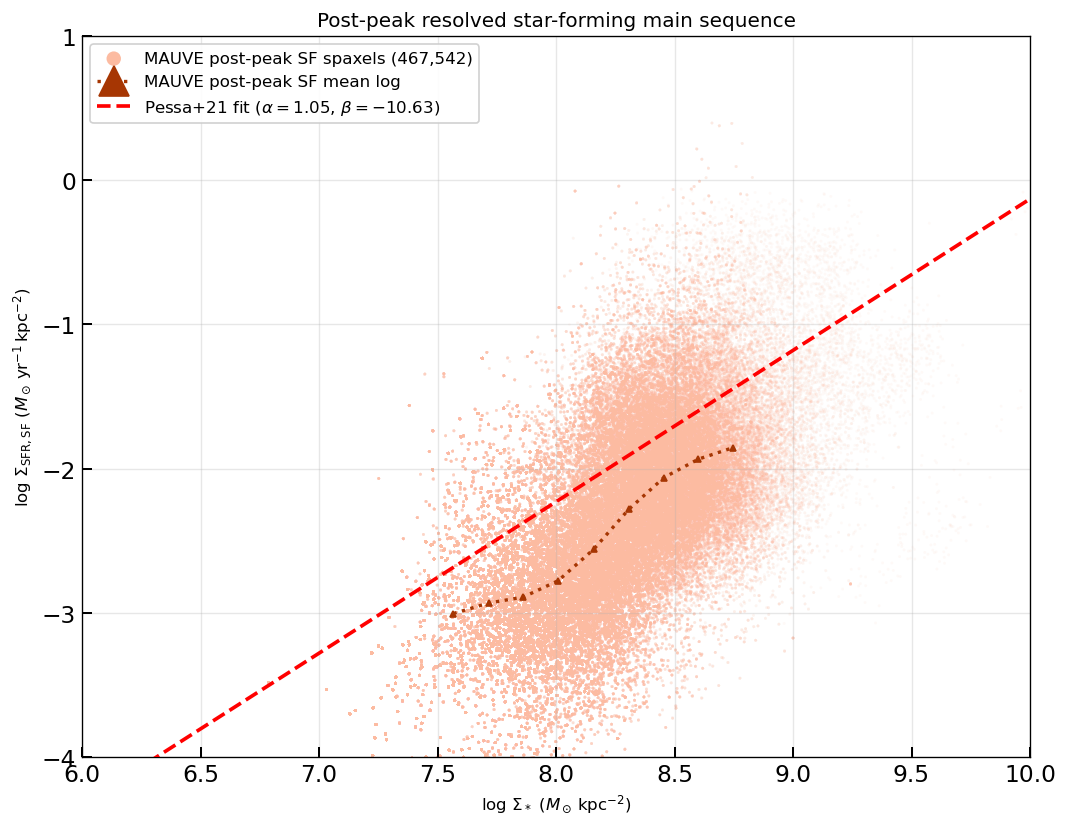


Post-peak rSFMS sample:
  Spaxels: 467,542
  Galaxies: IC3392, NGC4064, NGC4293, NGC4380, NGC4394, NGC4405, NGC4419, NGC4450, NGC4457, NGC4569, NGC4580, NGC4606, NGC4607, NGC4698
  Selection: finite pixels in LOGSFR_SURFACE_DENSITY_SF
  Trend mass range (central 95%): 7.484 to 8.832


In [5]:
# Post-peak rSFMS using all finite SF spaxels.
RSFMS_XRANGE = (6.0, 10.0)
RSFMS_YRANGE = (-4.0, 1.0)
RSFMS_BIN_WIDTH = 0.15
RSFMS_MIN_PIXELS_PER_BIN = 50
RSFMS_STAGE = 3
RSFMS_SCATTER_COLOR = "#FCBBA1"
RSFMS_CONTOUR_COLOR = "#E6550D"
RSFMS_MEAN_LOG_COLOR = "#A63603"


with fits.open(PROJECT_ROOT / "mauve_master_wiki_newclass.fits") as hdul:
    rsfms_infall_class = {
        row["Galaxy"].strip(): int(row["class"])
        for row in hdul[1].data
    }
rsfms_infall_class = add_combined_infall_classes(rsfms_infall_class)

rsfms_ready = (
    PRODUCTS["has_mass_map"]
    & PRODUCTS["has_sfr_map"]
)
rsfms_galaxies = PRODUCTS.index[rsfms_ready].tolist()
all_log_sigma_m = []
all_log_sigma_sfr = []
included_rsfms_galaxies = []

print("Collecting post-peak SF spaxels...")
for galaxy in rsfms_galaxies:
    stage = rsfms_infall_class.get(galaxy)
    if stage != RSFMS_STAGE:
        continue

    try:
        maps = load_selected_rsfms_maps(galaxy)
        selected = selected_rsfms_mask(*maps)
        log_sigma_m, log_sigma_sfr = maps
    except Exception as exc:
        print(f"  {galaxy}: skipped - {exc}")
        continue

    n_spaxels = int(selected.sum())
    print(f"  {galaxy}: {n_spaxels:,} post-peak SF spaxels")
    if n_spaxels == 0:
        continue
    included_rsfms_galaxies.append(galaxy)
    all_log_sigma_m.extend(log_sigma_m[selected].ravel())
    all_log_sigma_sfr.extend(log_sigma_sfr[selected].ravel())

all_log_sigma_m = np.asarray(all_log_sigma_m, dtype=float)
all_log_sigma_sfr = np.asarray(all_log_sigma_sfr, dtype=float)
if all_log_sigma_m.size == 0:
    raise RuntimeError("No valid post-peak SF spaxels found.")

# The mean-log trend uses exact central-95% bounds; under-populated bins remain
# as NaN gaps so the plotted curve never bridges unsupported mass intervals.
(
    trend_x,
    mean_log_sf,
    trend_counts,
    (trend_lo, trend_hi),
) = binned_rsfms_mean_trend(
    all_log_sigma_m,
    all_log_sigma_sfr,
    bin_width=RSFMS_BIN_WIDTH,
    min_pixels=RSFMS_MIN_PIXELS_PER_BIN,
)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(
    all_log_sigma_m,
    all_log_sigma_sfr,
    s=3,
    alpha=0.08,
    color=RSFMS_SCATTER_COLOR,
    edgecolors="none",
    rasterized=True,
    label=f"MAUVE post-peak SF spaxels ({all_log_sigma_m.size:,})",
    zorder=1,
)
ax.plot(
    trend_x,
    mean_log_sf,
    color=RSFMS_MEAN_LOG_COLOR,
    linestyle=":",
    marker="^",
    markersize=3.6,
    linewidth=2.0,
    label="MAUVE post-peak SF mean log",
    zorder=7,
)

pessa_alpha = 1.05
pessa_intercept = -10.63
x_pessa = np.linspace(*RSFMS_XRANGE, 200)
y_pessa = pessa_alpha * x_pessa + pessa_intercept
ax.plot(
    x_pessa,
    y_pessa,
    color="red",
    linestyle="--",
    linewidth=2.2,
    label=r"Pessa+21 fit ($\alpha=1.05$, $\beta=-10.63$)",
    zorder=8,
)

ax.set(
    xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
    ylabel=(
        r"$\log\,\Sigma_{\mathrm{SFR,SF}} \ "
        r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
    ),
    xlim=RSFMS_XRANGE,
    ylim=RSFMS_YRANGE,
    title="Post-peak resolved star-forming main sequence",
)
ax.grid(True, alpha=0.3)
legend = ax.legend(loc="upper left", framealpha=0.9, markerscale=5)
for handle in legend.legend_handles:
    if hasattr(handle, "set_alpha"):
        handle.set_alpha(1.0)
plt.tight_layout()
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_post_peak_SF.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_post_peak_SF.pdf", bbox_inches="tight")
plt.show()

print("\nPost-peak rSFMS sample:")
print(f"  Spaxels: {all_log_sigma_m.size:,}")
print(f"  Galaxies: {', '.join(included_rsfms_galaxies)}")
print("  Selection: finite pixels in LOGSFR_SURFACE_DENSITY_SF")
print(f"  Trend mass range (central 95%): {trend_lo:.3f} to {trend_hi:.3f}")


  NGC4189: 110,869 Pre-peak selected spaxels
  NGC4192: 255,471 Pre-peak selected spaxels
  NGC4254: 827,831 Pre-peak selected spaxels
  NGC4294: 69,207 Pre-peak selected spaxels
  NGC4298: 179,538 Close-to-peak selected spaxels
  NGC4302: 48,859 Close-to-peak selected spaxels
  NGC4321: 699,010 Pre-peak selected spaxels
  NGC4330: 39,372 Close-to-peak selected spaxels
  NGC4351: 30,940 Pre-peak selected spaxels
  NGC4383: 112,940 Pre-peak selected spaxels
  NGC4388: 22,228 Close-to-peak selected spaxels
  NGC4396: 86,178 Pre-peak selected spaxels
  NGC4402: 65,519 Close-to-peak selected spaxels
  NGC4501: 387,296 Close-to-peak selected spaxels
  NGC4522: 49,748 Close-to-peak selected spaxels
  NGC4535: 299,942 Pre-peak selected spaxels
  NGC4567_8: 291,172 Pre-peak selected spaxels
  NGC4694: 2,999 Close-to-peak selected spaxels


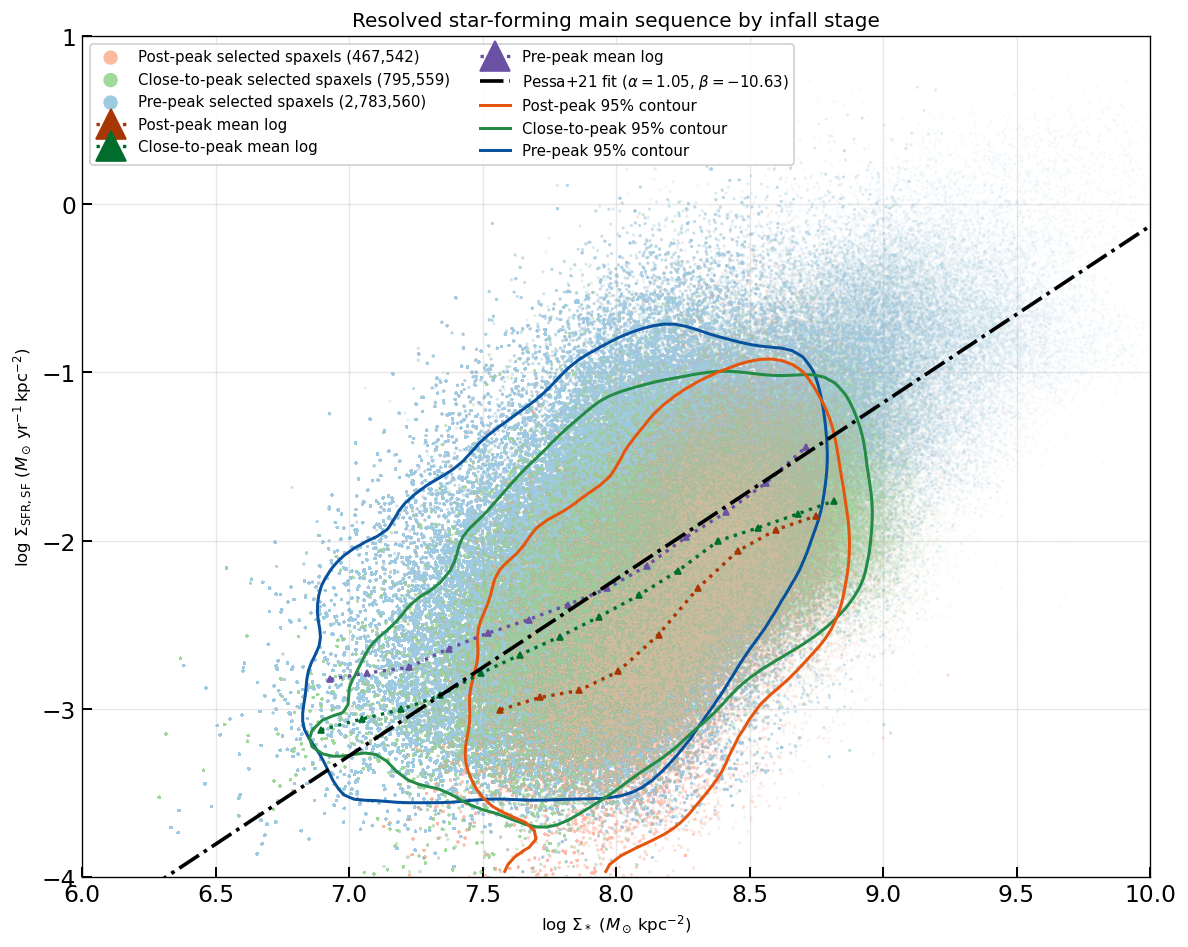


rSFMS sample by infall stage:
  Pre-peak: 2,783,560 spaxels from 10 galaxies
  Close-to-peak: 795,559 spaxels from 8 galaxies
  Post-peak: 467,542 spaxels from 14 galaxies
Selection: finite pixels in LOGSFR_SURFACE_DENSITY_SF
Trends: central 95% in stellar mass, 0.15-dex bins, >=50 pixels per bin


In [6]:
# Add pre-peak and close-to-peak samples using the same SF-spaxel definition.
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter

RSFMS_STAGE_LABELS = {
    1: "Pre-peak",
    2: "Close-to-peak",
    3: "Post-peak",
}
RSFMS_STAGE_STYLE = {
    1: {
        "scatter": "#9ECAE1",
        "contour": "#08519C",
        "mean_log": "#6A51A3",
        "alpha": 0.08,
        "zorder": 1.0,
    },
    2: {
        "scatter": "#A1D99B",
        "contour": "#238B45",
        "mean_log": "#006D2C",
        "alpha": 0.035,
        "zorder": 2.0,
    },
    3: {
        "scatter": "#FCBBA1",
        "contour": "#E6550D",
        "mean_log": "#A63603",
        "alpha": 0.025,
        "zorder": 3.0,
    },
}
STAGE_CONTOUR_ZORDER = 4.0
STAGE_TREND_ZORDER = 6.0
RSFMS_CONTOUR_BINS = 100
RSFMS_CONTOUR_SMOOTHING = 2.0

stage_log_sigma_m = {
    1: [],
    2: [],
    3: np.asarray(all_log_sigma_m, dtype=float),
}
stage_log_sigma_sfr = {
    1: [],
    2: [],
    3: np.asarray(all_log_sigma_sfr, dtype=float),
}
stage_galaxies = {
    1: [],
    2: [],
    3: list(included_rsfms_galaxies),
}

print("Collecting pre-peak and close-to-peak SF spaxels...")
for galaxy in rsfms_galaxies:
    stage = rsfms_infall_class.get(galaxy)
    if stage not in (1, 2):
        continue

    try:
        maps = load_selected_rsfms_maps(galaxy)
        selected = selected_rsfms_mask(*maps)
        log_sigma_m, log_sigma_sfr = maps
    except Exception as exc:
        print(f"  {galaxy}: skipped - {exc}")
        continue

    n_spaxels = int(selected.sum())
    print(f"  {galaxy}: {n_spaxels:,} {RSFMS_STAGE_LABELS[stage]} selected spaxels")
    if n_spaxels == 0:
        continue
    stage_galaxies[stage].append(galaxy)
    stage_log_sigma_m[stage].extend(log_sigma_m[selected].ravel())
    stage_log_sigma_sfr[stage].extend(log_sigma_sfr[selected].ravel())

for stage in (1, 2):
    stage_log_sigma_m[stage] = np.asarray(stage_log_sigma_m[stage], dtype=float)
    stage_log_sigma_sfr[stage] = np.asarray(stage_log_sigma_sfr[stage], dtype=float)


def plot_stage_95_contour(ax, x, y, *, color, zorder):
    """Plot one 95%-population contour for a stage's central-95% mass sample."""
    trend_lo, trend_hi = np.nanpercentile(x, [2.5, 97.5])
    central = (x >= trend_lo) & (x <= trend_hi)
    histogram, xedges, yedges = np.histogram2d(
        x[central],
        y[central],
        bins=RSFMS_CONTOUR_BINS,
        range=[RSFMS_XRANGE, RSFMS_YRANGE],
    )
    smoothed = gaussian_filter(histogram, sigma=RSFMS_CONTOUR_SMOOTHING)
    ranked = np.sort(smoothed[smoothed > 0].ravel())[::-1]
    if ranked.size == 0:
        return None
    cumulative = np.cumsum(ranked)
    level_index = np.searchsorted(cumulative, 0.95 * cumulative[-1])
    level_95 = ranked[min(level_index, ranked.size - 1)]
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    ycenters = 0.5 * (yedges[:-1] + yedges[1:])
    return ax.contour(
        xcenters,
        ycenters,
        smoothed.T,
        levels=[level_95],
        colors=[color],
        linewidths=1.8,
        linestyles="-",
        zorder=zorder,
    )


fig, ax = plt.subplots(figsize=(10, 8))

# Scatter: pre-peak lowest, close-to-peak next, post-peak highest.
for stage in (3, 2, 1):
    x = stage_log_sigma_m[stage]
    y = stage_log_sigma_sfr[stage]
    if x.size == 0:
        continue
    style = RSFMS_STAGE_STYLE[stage]
    ax.scatter(
        x,
        y,
        s=3,
        alpha=style["alpha"],
        color=style["scatter"],
        edgecolors="none",
        rasterized=True,
        zorder=style["zorder"],
        label=f"{RSFMS_STAGE_LABELS[stage]} selected spaxels ({x.size:,})",
    )

# One 95%-population contour per stage, above scatter and below the mean-log trends.
contour_handles = []
for stage in (3, 2, 1):
    x = stage_log_sigma_m[stage]
    y = stage_log_sigma_sfr[stage]
    if x.size == 0:
        continue
    style = RSFMS_STAGE_STYLE[stage]
    plot_stage_95_contour(
        ax,
        x,
        y,
        color=style["contour"],
        zorder=STAGE_CONTOUR_ZORDER + 0.1 * style["zorder"],
    )
    contour_handles.append(
        Line2D(
            [0], [0], color=style["contour"], linewidth=1.8,
            label=f"{RSFMS_STAGE_LABELS[stage]} 95% contour",
        )
    )

# Mean-log curves are above every scatter and contour layer.
for stage in (3, 2, 1):
    x = stage_log_sigma_m[stage]
    y = stage_log_sigma_sfr[stage]
    if x.size == 0:
        continue
    style = RSFMS_STAGE_STYLE[stage]
    (
        trend_x,
        mean_log,
        trend_counts,
        trend_limits,
    ) = binned_rsfms_mean_trend(
        x,
        y,
        bin_width=RSFMS_BIN_WIDTH,
        min_pixels=RSFMS_MIN_PIXELS_PER_BIN,
    )
    ax.plot(
        trend_x,
        mean_log,
        color=style["mean_log"],
        linestyle=":",
        marker="^",
        markersize=3.6,
        linewidth=2.0,
        zorder=STAGE_TREND_ZORDER + style["zorder"] + 0.1,
        label=f"{RSFMS_STAGE_LABELS[stage]} mean log",
    )

x_pessa = np.linspace(*RSFMS_XRANGE, 200)
y_pessa = pessa_alpha * x_pessa + pessa_intercept
ax.plot(
    x_pessa,
    y_pessa,
    color="black",
    linestyle="-.",
    linewidth=2.2,
    zorder=10.0,
    label=r"Pessa+21 fit ($\alpha=1.05$, $\beta=-10.63$)",
)

ax.set(
    xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
    ylabel=(
        r"$\log\,\Sigma_{\mathrm{SFR,SF}} \ "
        r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
    ),
    xlim=RSFMS_XRANGE,
    ylim=RSFMS_YRANGE,
    title="Resolved star-forming main sequence by infall stage",
)
ax.grid(True, alpha=0.3)
handles, labels = ax.get_legend_handles_labels()
handles.extend(contour_handles)
labels.extend(handle.get_label() for handle in contour_handles)
legend = ax.legend(
    handles=handles,
    labels=labels,
    loc="upper left",
    ncol=2,
    fontsize=9,
    framealpha=0.9,
    markerscale=5,
)
for handle in legend.legend_handles:
    if hasattr(handle, "set_alpha"):
        handle.set_alpha(1.0)
plt.tight_layout()
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_all_infall_stages_SF.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_all_infall_stages_SF.pdf", bbox_inches="tight")
plt.show()

print("\nrSFMS sample by infall stage:")
for stage in (1, 2, 3):
    print(
        f"  {RSFMS_STAGE_LABELS[stage]}: "
        f"{stage_log_sigma_m[stage].size:,} spaxels from "
        f"{len(stage_galaxies[stage])} galaxies"
    )
print("Selection: finite pixels in LOGSFR_SURFACE_DENSITY_SF")
print(
    f"Trends: central 95% in stellar mass, {RSFMS_BIN_WIDTH:g}-dex bins, "
    f">={RSFMS_MIN_PIXELS_PER_BIN} pixels per bin"
)


## Individual post-peak galaxy rSFMS checks

The pooled post-peak relation may suggest an SFR enhancement, but that
signal could be driven by only one or two systems. The following cells therefore
preserve one individual-plot cell for every post-peak galaxy in the infall catalog; calls for galaxies without current products are commented out. Available galaxies use all finite
pixels in `LOGSFR_SURFACE_DENSITY_SF`, the central-95%
stellar-mass range, 0.15-dex bins, ≥50-pixel requirement, 95%-population contour,
and Pessa et al. (2021) reference as the combined comparison.


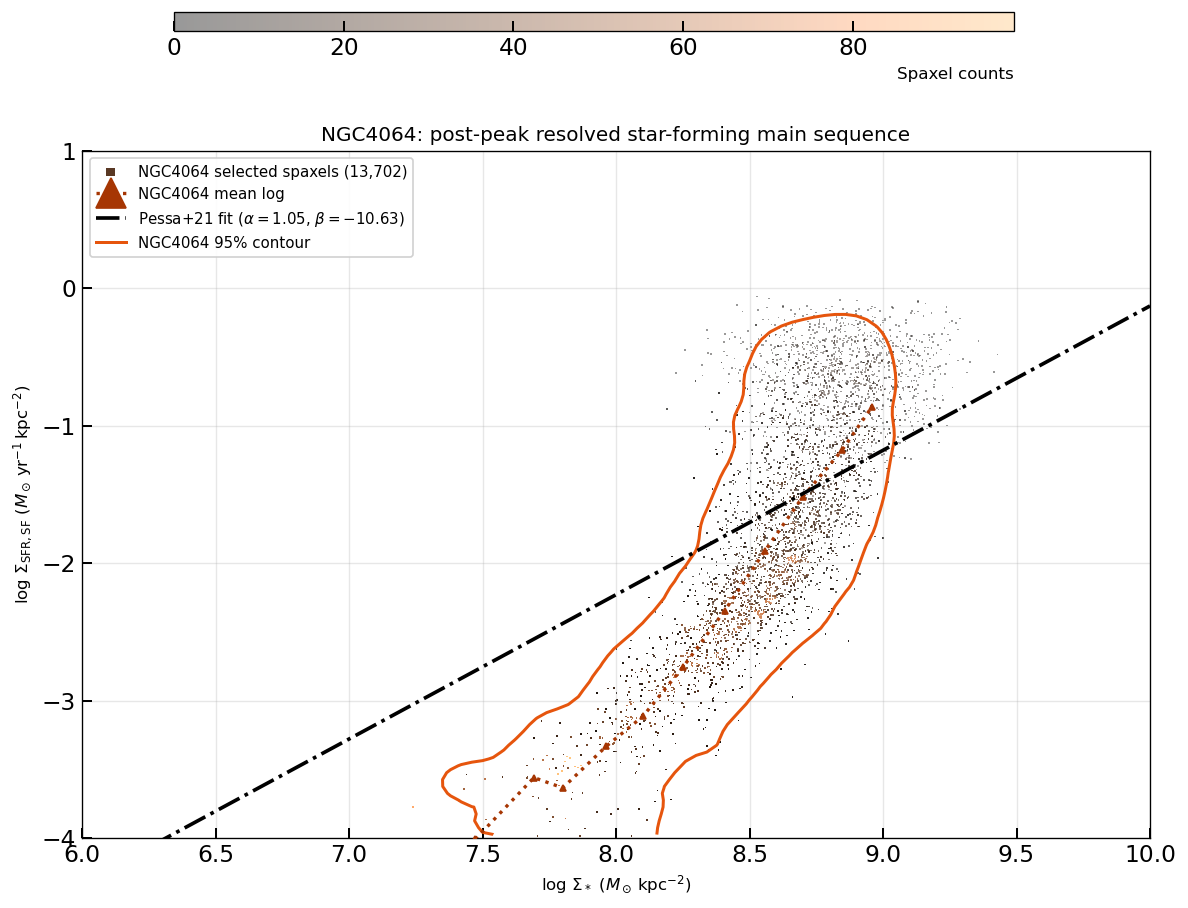

NGC4064: 13,702 selected spaxels
  Central-95% stellar-mass range: 7.430 to 8.992
  Valid trend bins: 11 of 11


In [7]:
POST_PEAK_GALAXIES = [
    "NGC4064",
    "NGC4216",
    "NGC4293",
    "NGC4380",
    "NGC4394",
    "NGC4405",
    "NGC4419",
    "NGC4450",
    "IC3392",
    "NGC4457",
    "NGC4548",
    "NGC4569",
    "NGC4579",
    "NGC4580",
    "NGC4606",
    "NGC4607",
    "NGC4689",
    "NGC4698",
]

POST_PEAK_AVAILABLE_GALAXIES = [
    "NGC4064",
    "NGC4293",
    "NGC4380",
    "NGC4394",
    "NGC4405",
    "NGC4419",
    "NGC4450",
    "IC3392",
    "NGC4457",
    "NGC4569",
    "NGC4580",
    "NGC4606",
    "NGC4607",
    "NGC4698",
]


def plot_individual_postpeak_rsfms(galaxy):
    """Plot the selected rSFMS, mean-log trend, and 95% contour for one galaxy."""
    if galaxy not in rsfms_galaxies:
        raise ValueError(f"{galaxy} is not available for the rSFMS analysis")
    if rsfms_infall_class.get(galaxy) != RSFMS_STAGE:
        raise ValueError(f"{galaxy} is not a post-peak galaxy")

    maps = load_selected_rsfms_maps(galaxy)
    selected = selected_rsfms_mask(*maps)
    log_sigma_m, log_sigma_sfr = maps
    x = np.asarray(log_sigma_m[selected], dtype=float)
    y = np.asarray(log_sigma_sfr[selected], dtype=float)
    if x.size == 0:
        raise RuntimeError(f"{galaxy}: no finite SF spaxels")

    (
        trend_x,
        mean_log,
        trend_counts,
        (trend_lo, trend_hi),
    ) = binned_rsfms_mean_trend(
        x,
        y,
        bin_width=RSFMS_BIN_WIDTH,
        min_pixels=RSFMS_MIN_PIXELS_PER_BIN,
    )

    fig, ax = plt.subplots(figsize=(10, 8))

    # Match cell 6: density-coloured scatter for this galaxy only.
    histogram, xedges, yedges = np.histogram2d(
        x,
        y,
        bins=100,
        range=[RSFMS_XRANGE, RSFMS_YRANGE],
    )
    x_index = np.clip(np.digitize(x, xedges) - 1, 0, histogram.shape[0] - 1)
    y_index = np.clip(np.digitize(y, yedges) - 1, 0, histogram.shape[1] - 1)
    density = histogram[x_index, y_index]
    scatter = ax.scatter(
        x,
        y,
        c=density,
        s=1,
        alpha=0.4,
        marker=",",
        cmap="copper",
        edgecolors="none",
        rasterized=True,
        zorder=1,
        label=f"{galaxy} selected spaxels ({x.size:,})",
    )

    # Keep cell 9's single 95%-population contour below the mean-log curve.
    plot_stage_95_contour(
        ax,
        x,
        y,
        color=RSFMS_CONTOUR_COLOR,
        zorder=STAGE_CONTOUR_ZORDER,
    )
    contour_handle = Line2D(
        [0],
        [0],
        color=RSFMS_CONTOUR_COLOR,
        linewidth=1.8,
        label=f"{galaxy} 95% contour",
    )

    ax.plot(
        trend_x,
        mean_log,
        color=RSFMS_MEAN_LOG_COLOR,
        linestyle=":",
        marker="^",
        markersize=3.6,
        linewidth=2.0,
        zorder=7.1,
        label=f"{galaxy} mean log",
    )

    x_pessa = np.linspace(*RSFMS_XRANGE, 200)
    y_pessa = pessa_alpha * x_pessa + pessa_intercept
    ax.plot(
        x_pessa,
        y_pessa,
        color="black",
        linestyle="-.",
        linewidth=2.2,
        zorder=8.0,
        label=r"Pessa+21 fit ($\alpha=1.05$, $\beta=-10.63$)",
    )

    ax.set(
        xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
        ylabel=(
            r"$\log\,\Sigma_{\mathrm{SFR,SF}} \ "
            r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
        ),
        xlim=RSFMS_XRANGE,
        ylim=RSFMS_YRANGE,
        title=f"{galaxy}: post-peak resolved star-forming main sequence",
    )
    ax.grid(True, alpha=0.3)
    handles, labels = ax.get_legend_handles_labels()
    handles.append(contour_handle)
    labels.append(contour_handle.get_label())
    legend = ax.legend(
        handles=handles,
        labels=labels,
        loc="upper left",
        ncol=1,
        fontsize=9,
        framealpha=0.9,
        markerscale=5,
    )
    for handle in legend.legend_handles:
        if hasattr(handle, "set_alpha"):
            handle.set_alpha(1.0)

    plt.tight_layout(rect=[0, 0, 1, 0.84])
    colorbar_axis = fig.add_axes([0.15, 0.92, 0.7, 0.02])
    colorbar = plt.colorbar(scatter, cax=colorbar_axis, orientation="horizontal")
    colorbar.set_label("Spaxel counts", loc="right")
    # plt.savefig(OUTDIR / f"{galaxy}_rSFMS_post_peak_SF.png", dpi=600, bbox_inches="tight")
    # plt.savefig(OUTDIR / f"{galaxy}_rSFMS_post_peak_SF.pdf", bbox_inches="tight")
    plt.show()

    print(f"{galaxy}: {x.size:,} selected spaxels")
    print(f"  Central-95% stellar-mass range: {trend_lo:.3f} to {trend_hi:.3f}")
    print(
        f"  Valid trend bins: {np.count_nonzero(trend_counts >= RSFMS_MIN_PIXELS_PER_BIN)} "
        f"of {trend_counts.size}"
    )


plot_individual_postpeak_rsfms("NGC4064")


In [8]:
# plot_individual_postpeak_rsfms("NGC4216")  # unavailable: required current rSFMS products are missing


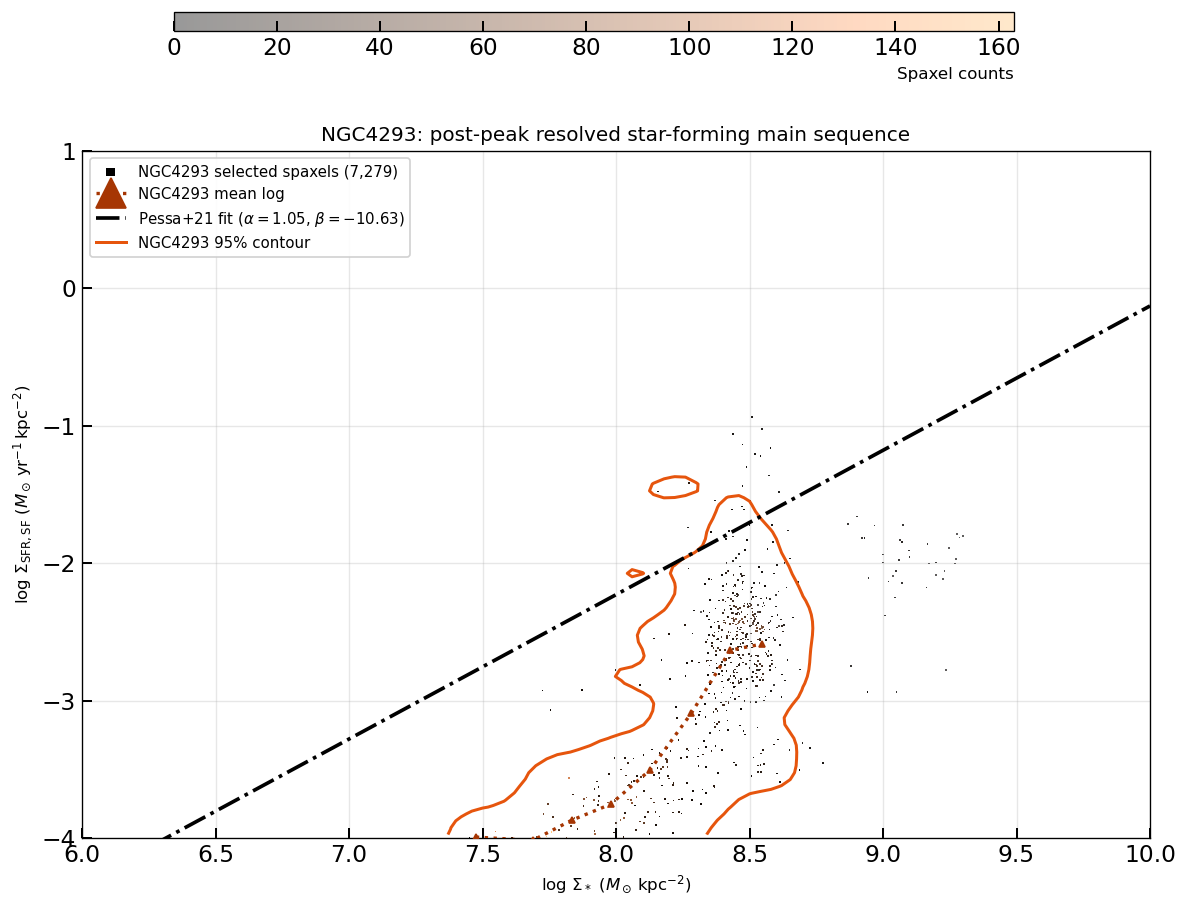

NGC4293: 7,279 selected spaxels
  Central-95% stellar-mass range: 7.451 to 8.625
  Valid trend bins: 8 of 8


In [9]:
plot_individual_postpeak_rsfms("NGC4293")


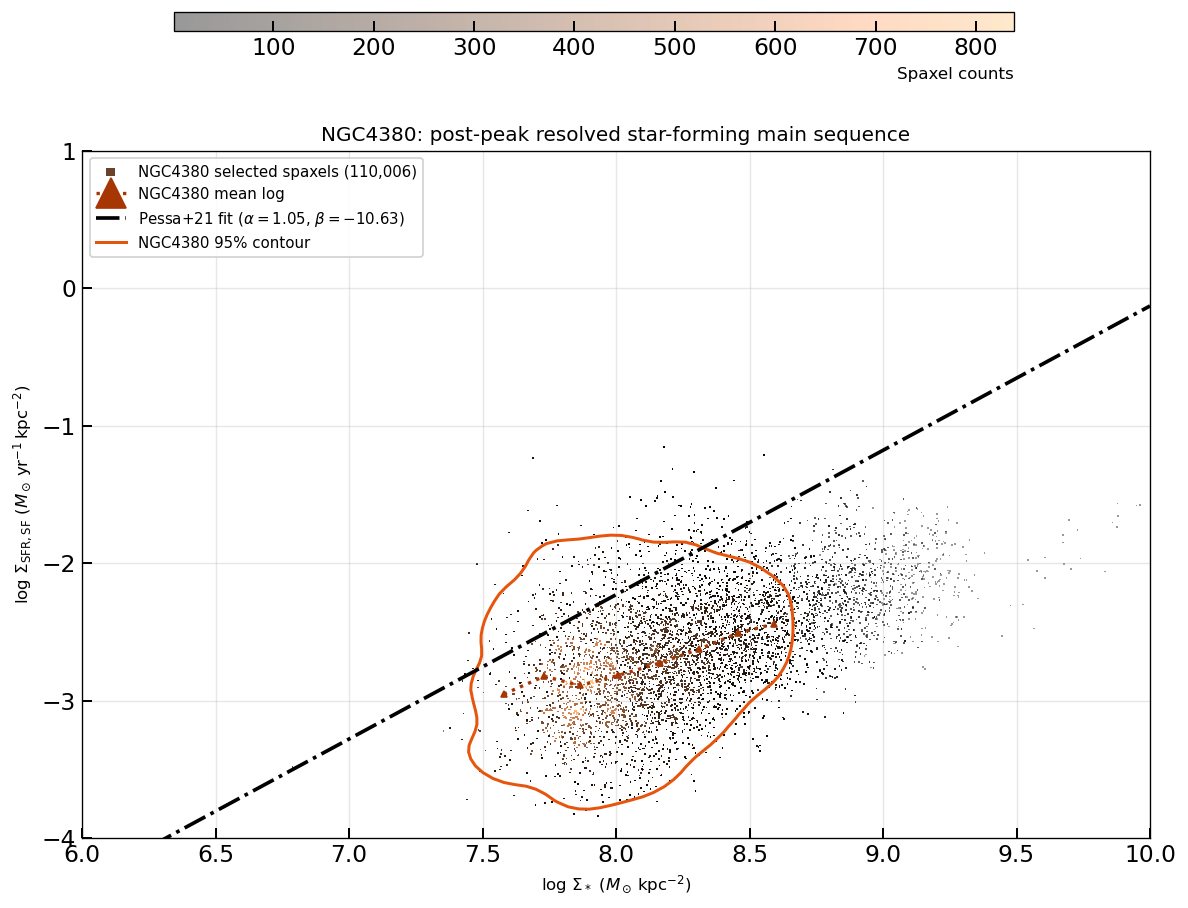

NGC4380: 110,006 selected spaxels
  Central-95% stellar-mass range: 7.491 to 8.657
  Valid trend bins: 8 of 8


In [10]:
plot_individual_postpeak_rsfms("NGC4380")


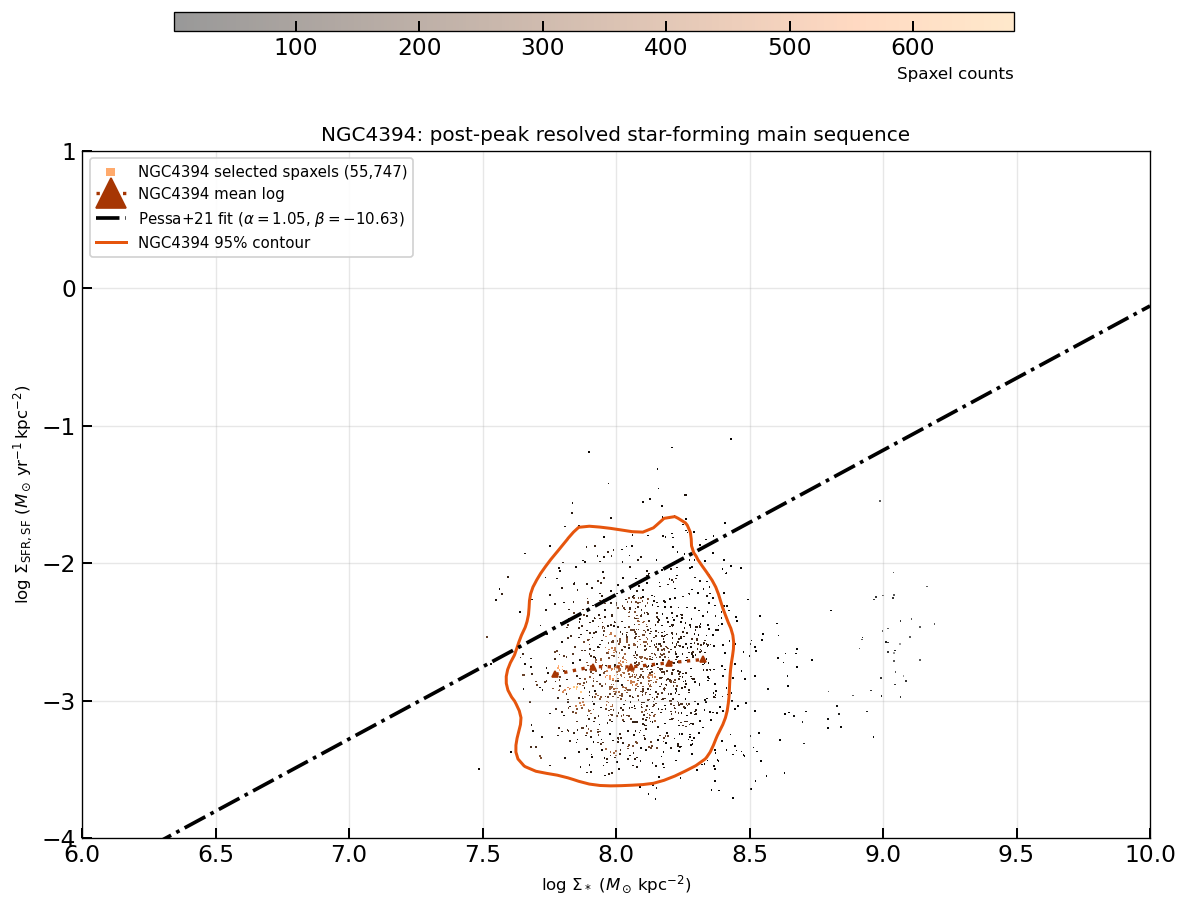

NGC4394: 55,747 selected spaxels
  Central-95% stellar-mass range: 7.682 to 8.384
  Valid trend bins: 5 of 5


In [11]:
plot_individual_postpeak_rsfms("NGC4394")


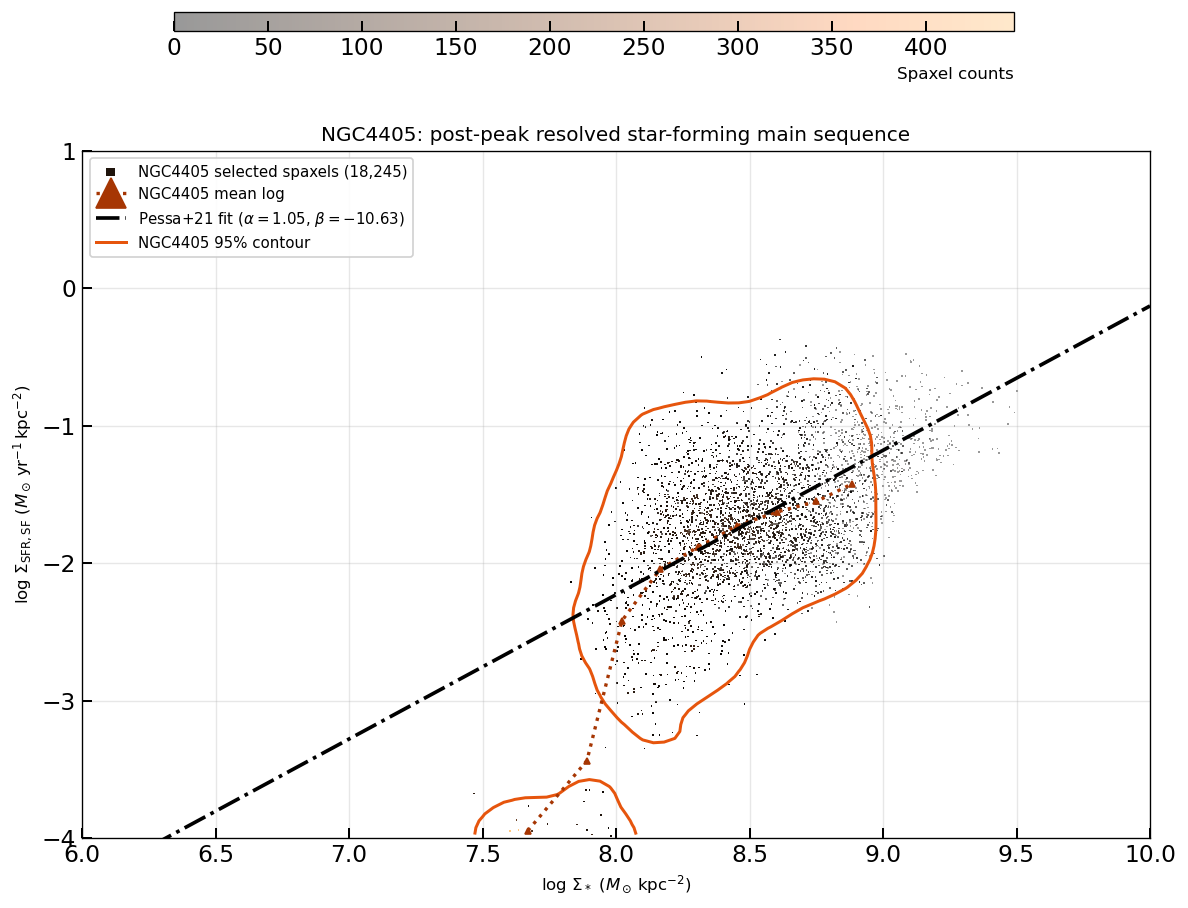

NGC4405: 18,245 selected spaxels
  Central-95% stellar-mass range: 7.634 to 8.938
  Valid trend bins: 9 of 9


In [12]:
plot_individual_postpeak_rsfms("NGC4405")


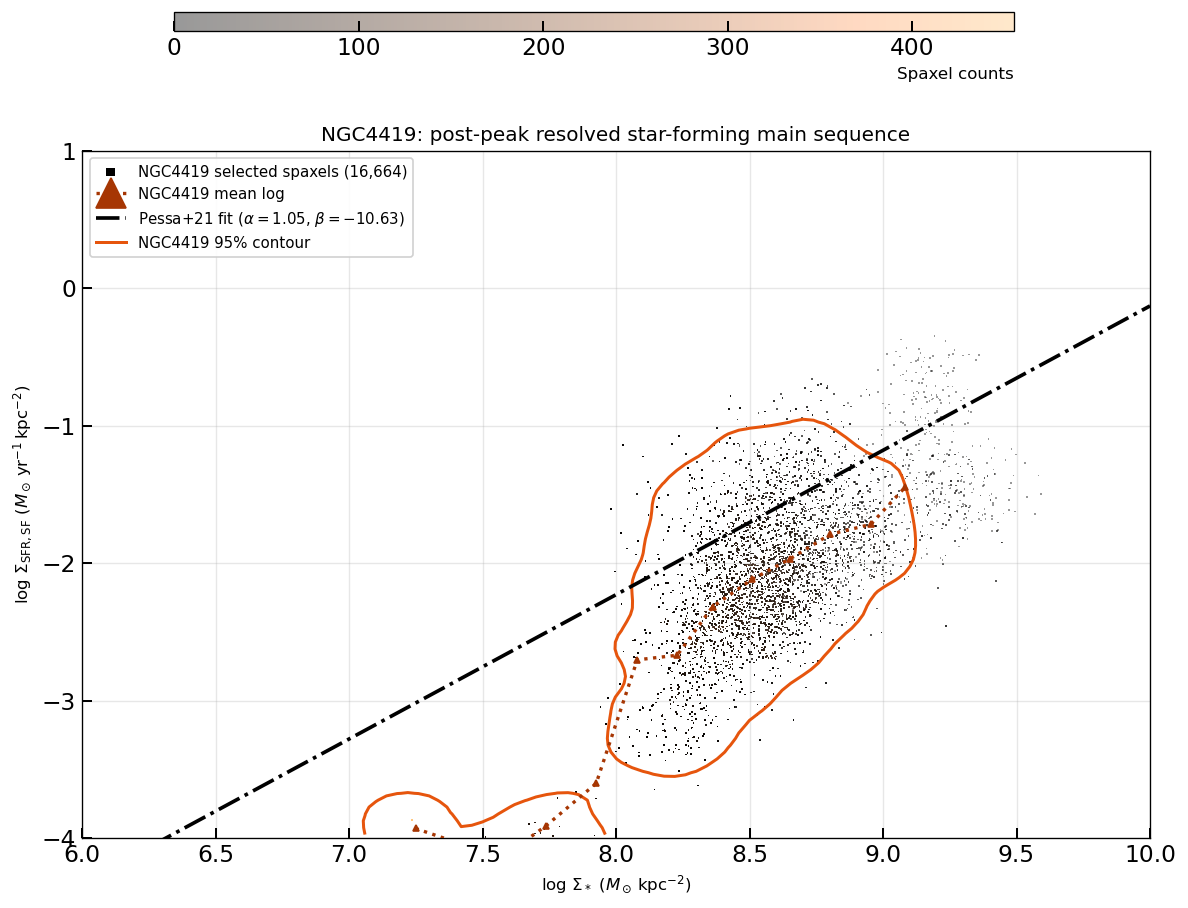

NGC4419: 16,664 selected spaxels
  Central-95% stellar-mass range: 7.236 to 9.123
  Valid trend bins: 13 of 13


In [13]:
plot_individual_postpeak_rsfms("NGC4419")


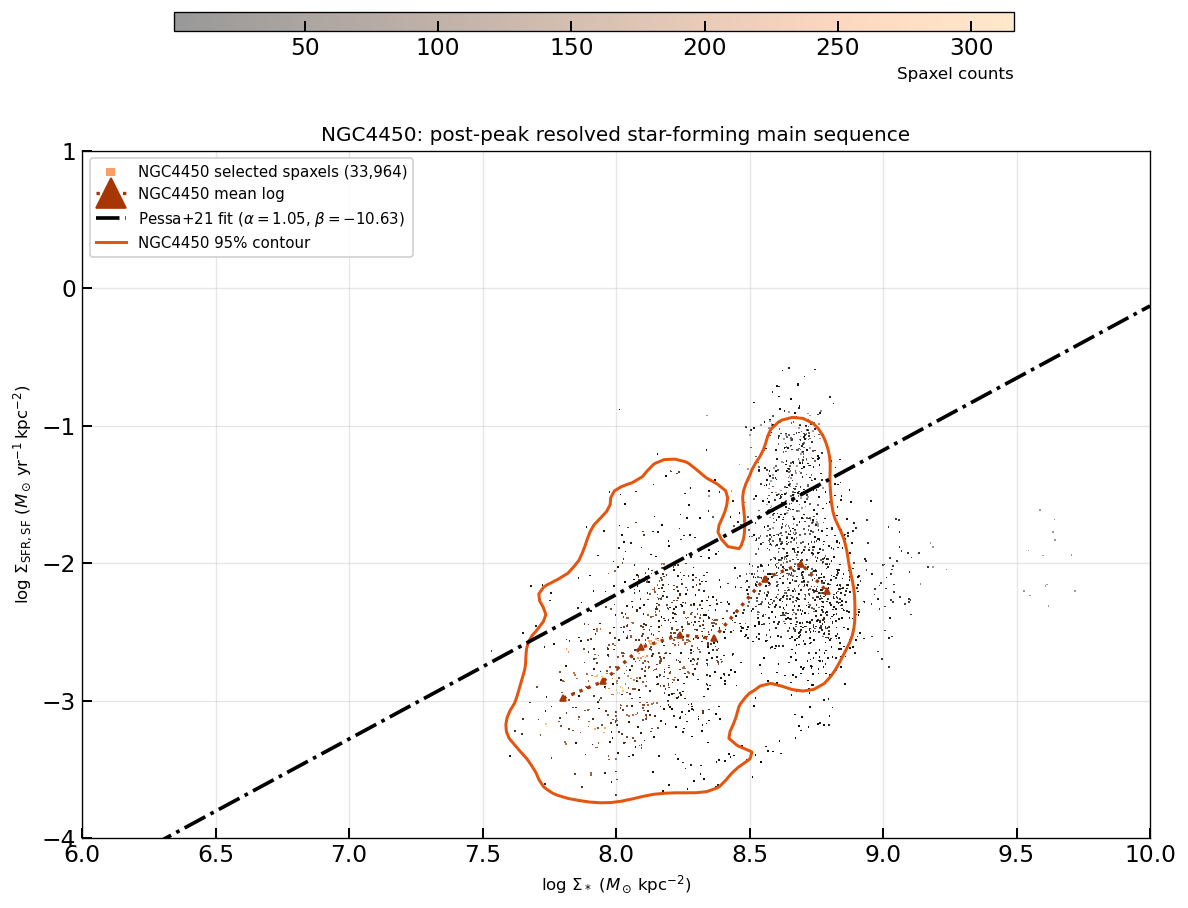

NGC4450: 33,964 selected spaxels
  Central-95% stellar-mass range: 7.717 to 8.822
  Valid trend bins: 8 of 8


In [14]:
plot_individual_postpeak_rsfms("NGC4450")


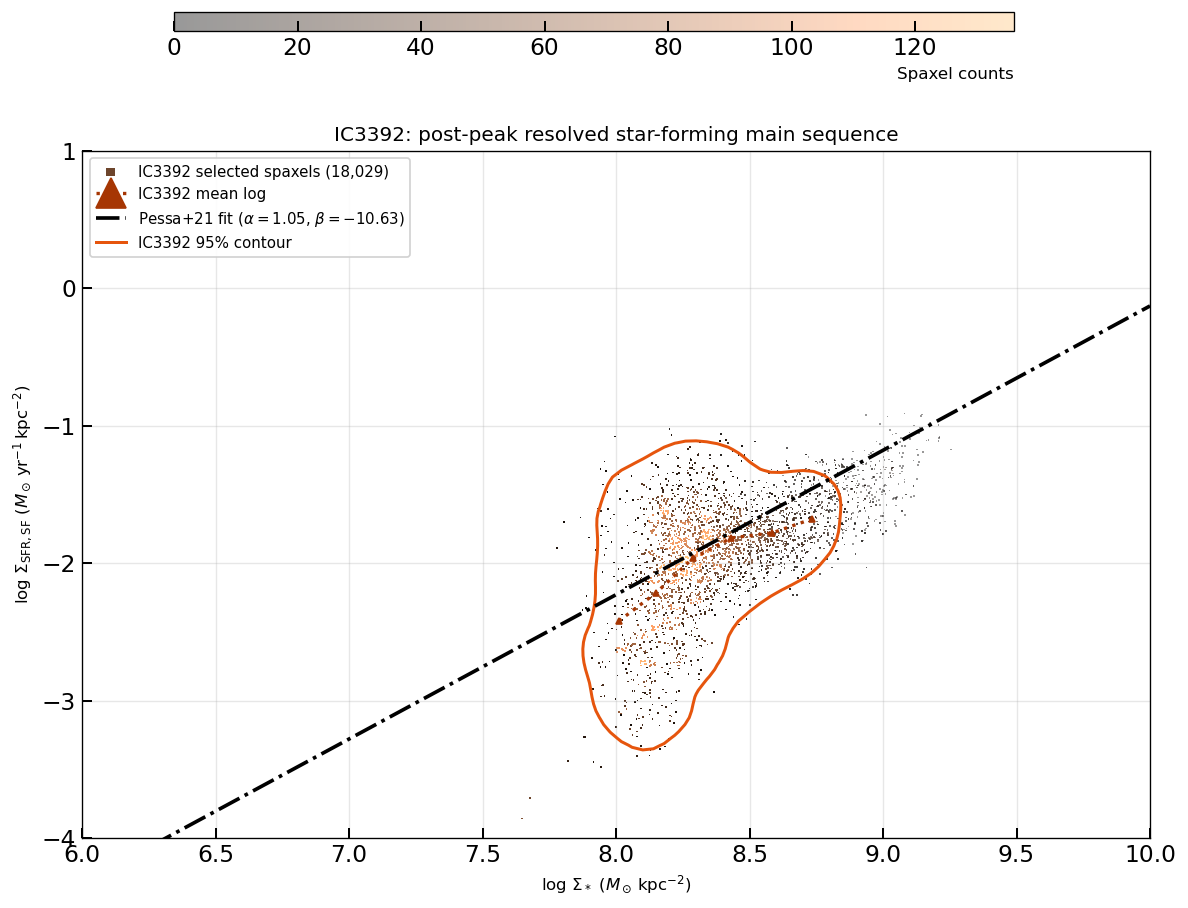

IC3392: 18,029 selected spaxels
  Central-95% stellar-mass range: 7.918 to 8.814
  Valid trend bins: 6 of 6


In [15]:
plot_individual_postpeak_rsfms("IC3392")


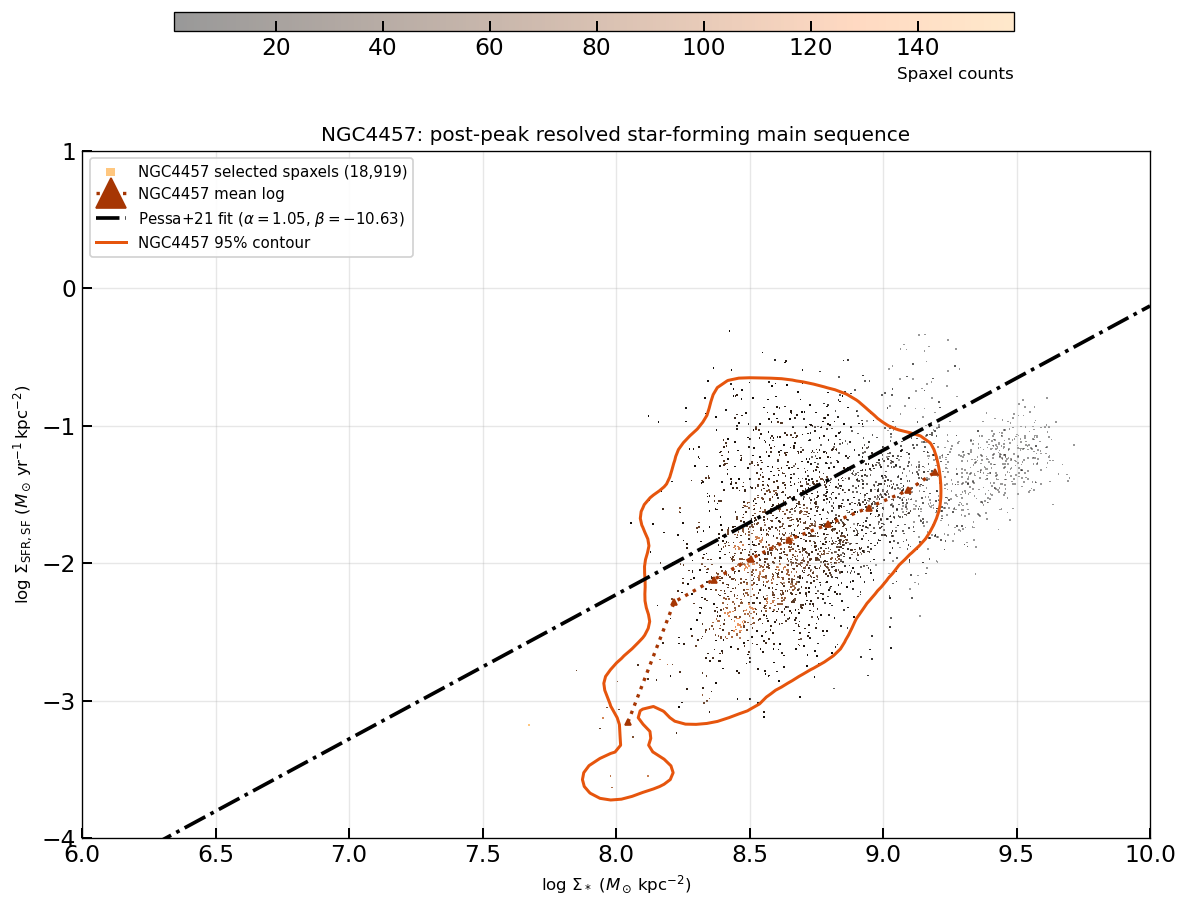

NGC4457: 18,919 selected spaxels
  Central-95% stellar-mass range: 7.979 to 9.212
  Valid trend bins: 9 of 9


In [16]:
plot_individual_postpeak_rsfms("NGC4457")


In [17]:
# plot_individual_postpeak_rsfms("NGC4548")  # unavailable: required current rSFMS products are missing


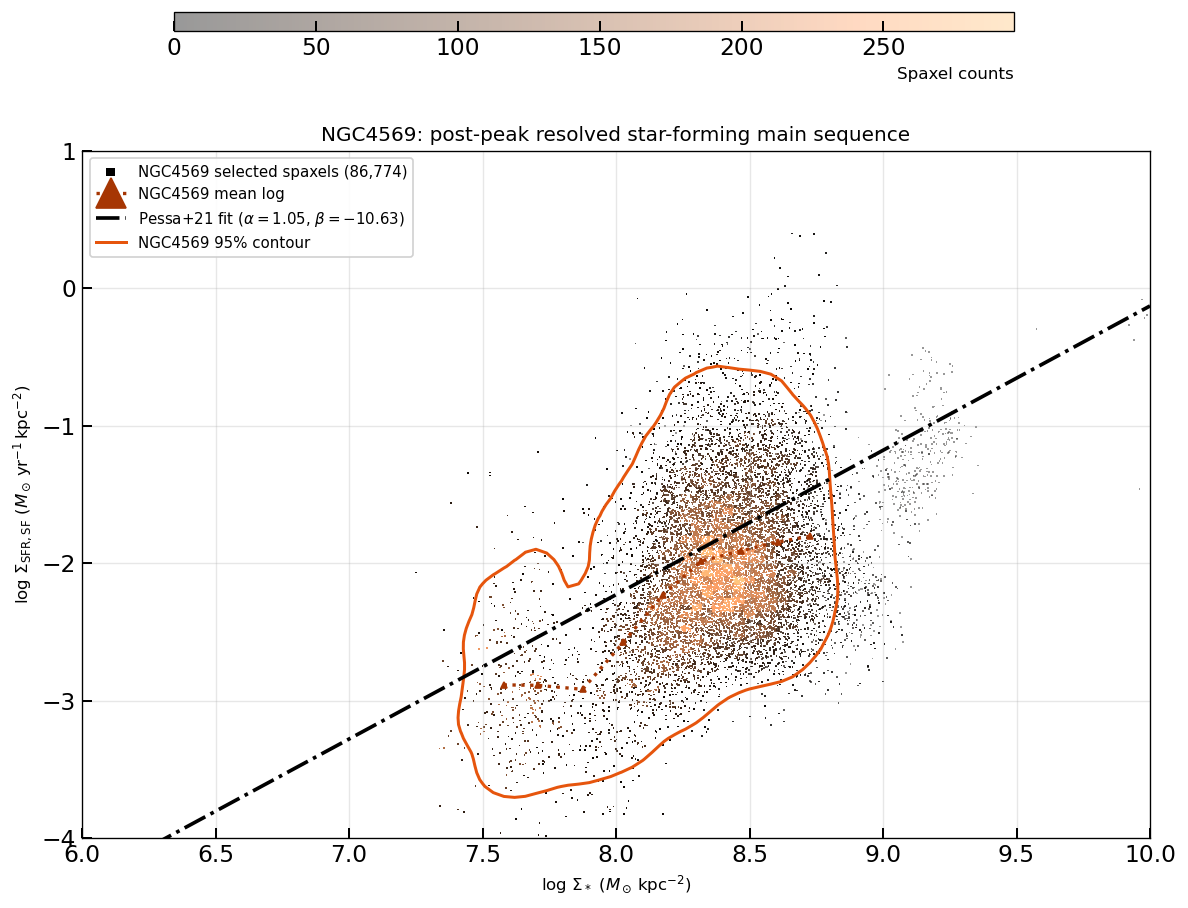

NGC4569: 86,774 selected spaxels
  Central-95% stellar-mass range: 7.494 to 8.760
  Valid trend bins: 9 of 9


In [18]:
plot_individual_postpeak_rsfms("NGC4569")


In [19]:
# plot_individual_postpeak_rsfms("NGC4579")  # unavailable: required current rSFMS products are missing


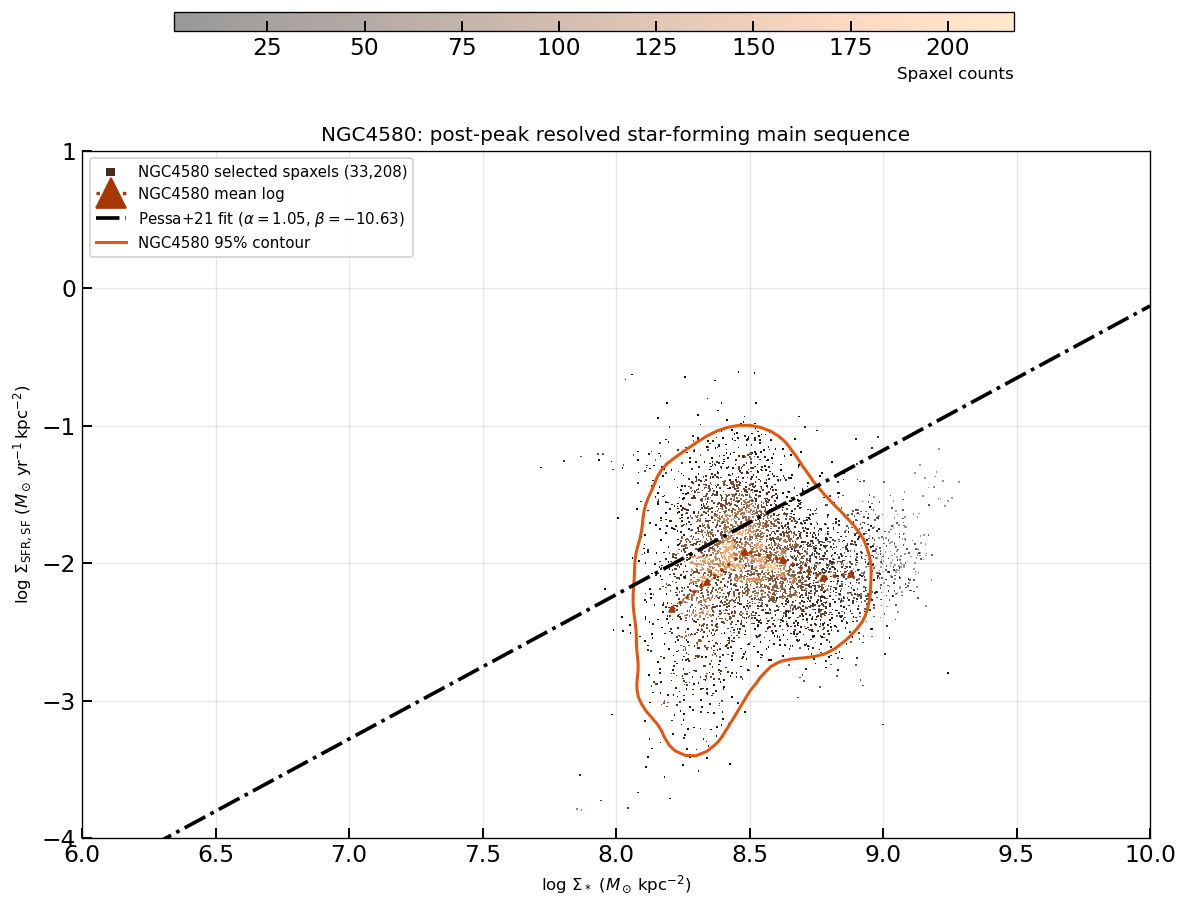

NGC4580: 33,208 selected spaxels
  Central-95% stellar-mass range: 8.111 to 8.902
  Valid trend bins: 6 of 6


In [20]:
plot_individual_postpeak_rsfms("NGC4580")


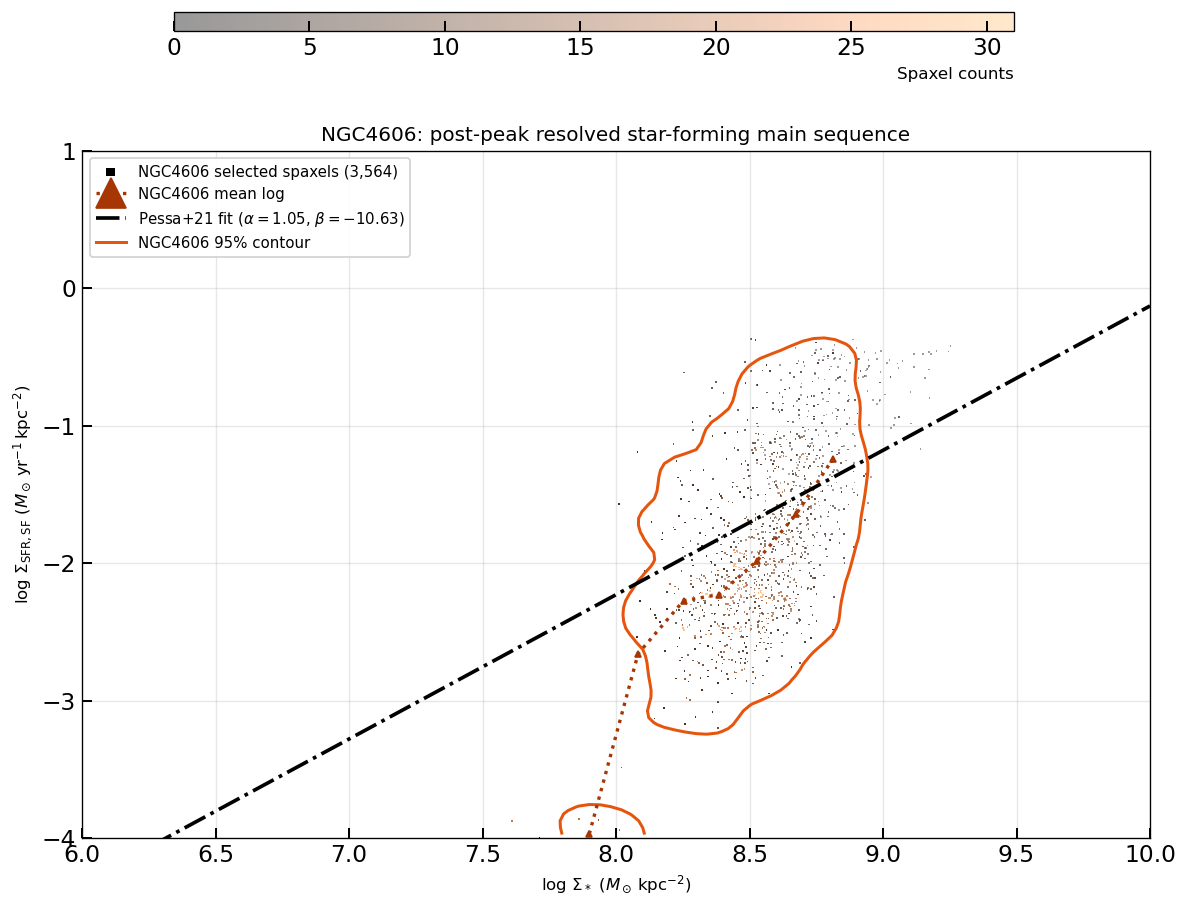

NGC4606: 3,564 selected spaxels
  Central-95% stellar-mass range: 7.856 to 8.889
  Valid trend bins: 7 of 7


In [21]:
plot_individual_postpeak_rsfms("NGC4606")


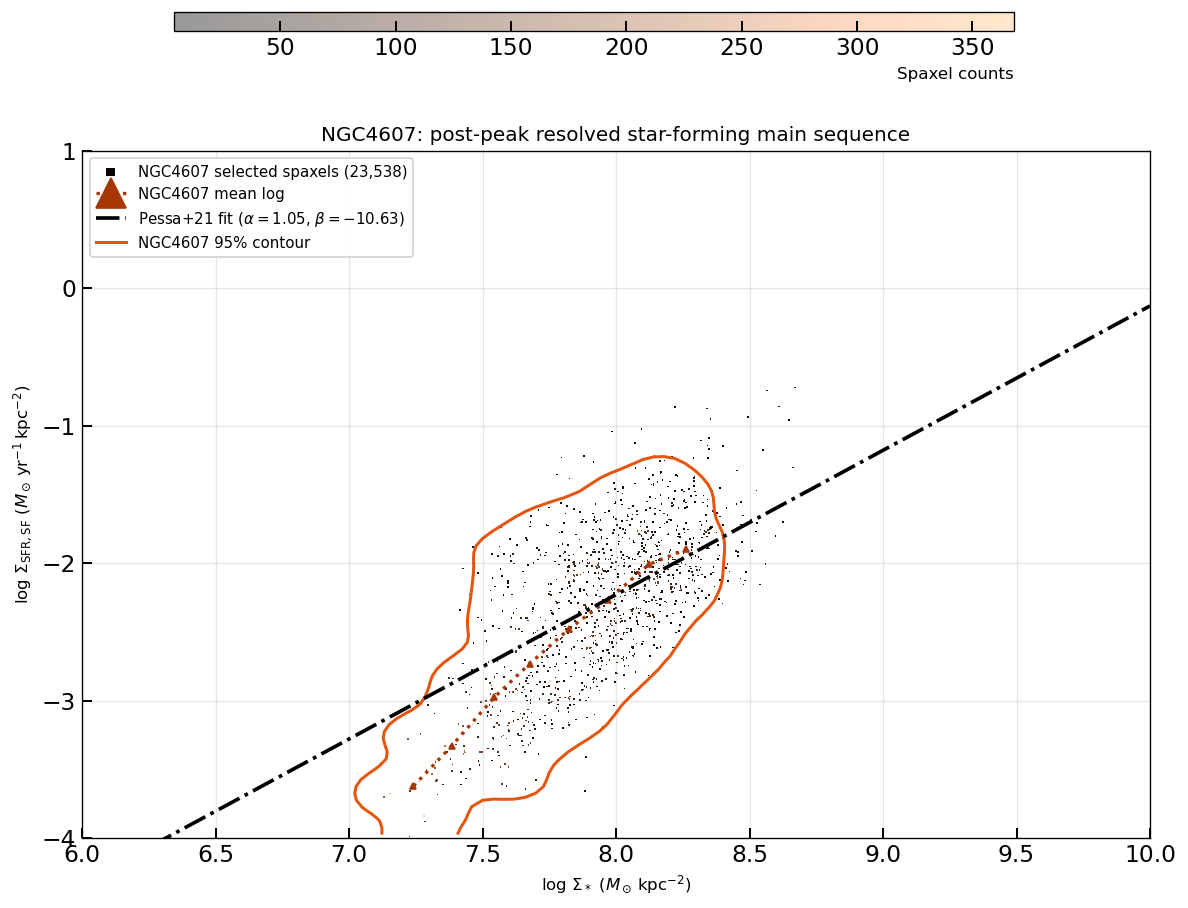

NGC4607: 23,538 selected spaxels
  Central-95% stellar-mass range: 7.153 to 8.342
  Valid trend bins: 8 of 8


In [22]:
plot_individual_postpeak_rsfms("NGC4607")


In [23]:
# plot_individual_postpeak_rsfms("NGC4689")  # unavailable: required current rSFMS products are missing


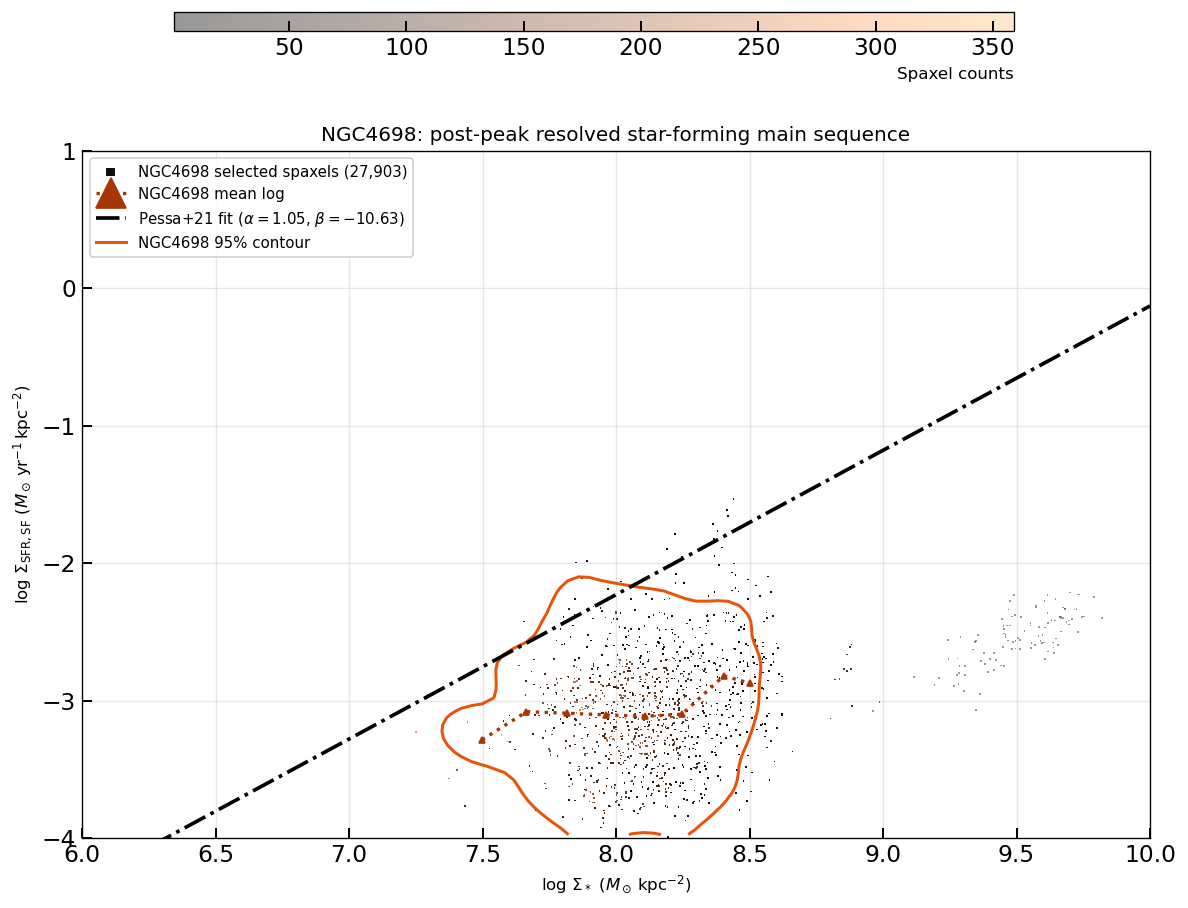

NGC4698: 27,903 selected spaxels
  Central-95% stellar-mass range: 7.434 to 8.520
  Valid trend bins: 8 of 8


In [24]:
plot_individual_postpeak_rsfms("NGC4698")


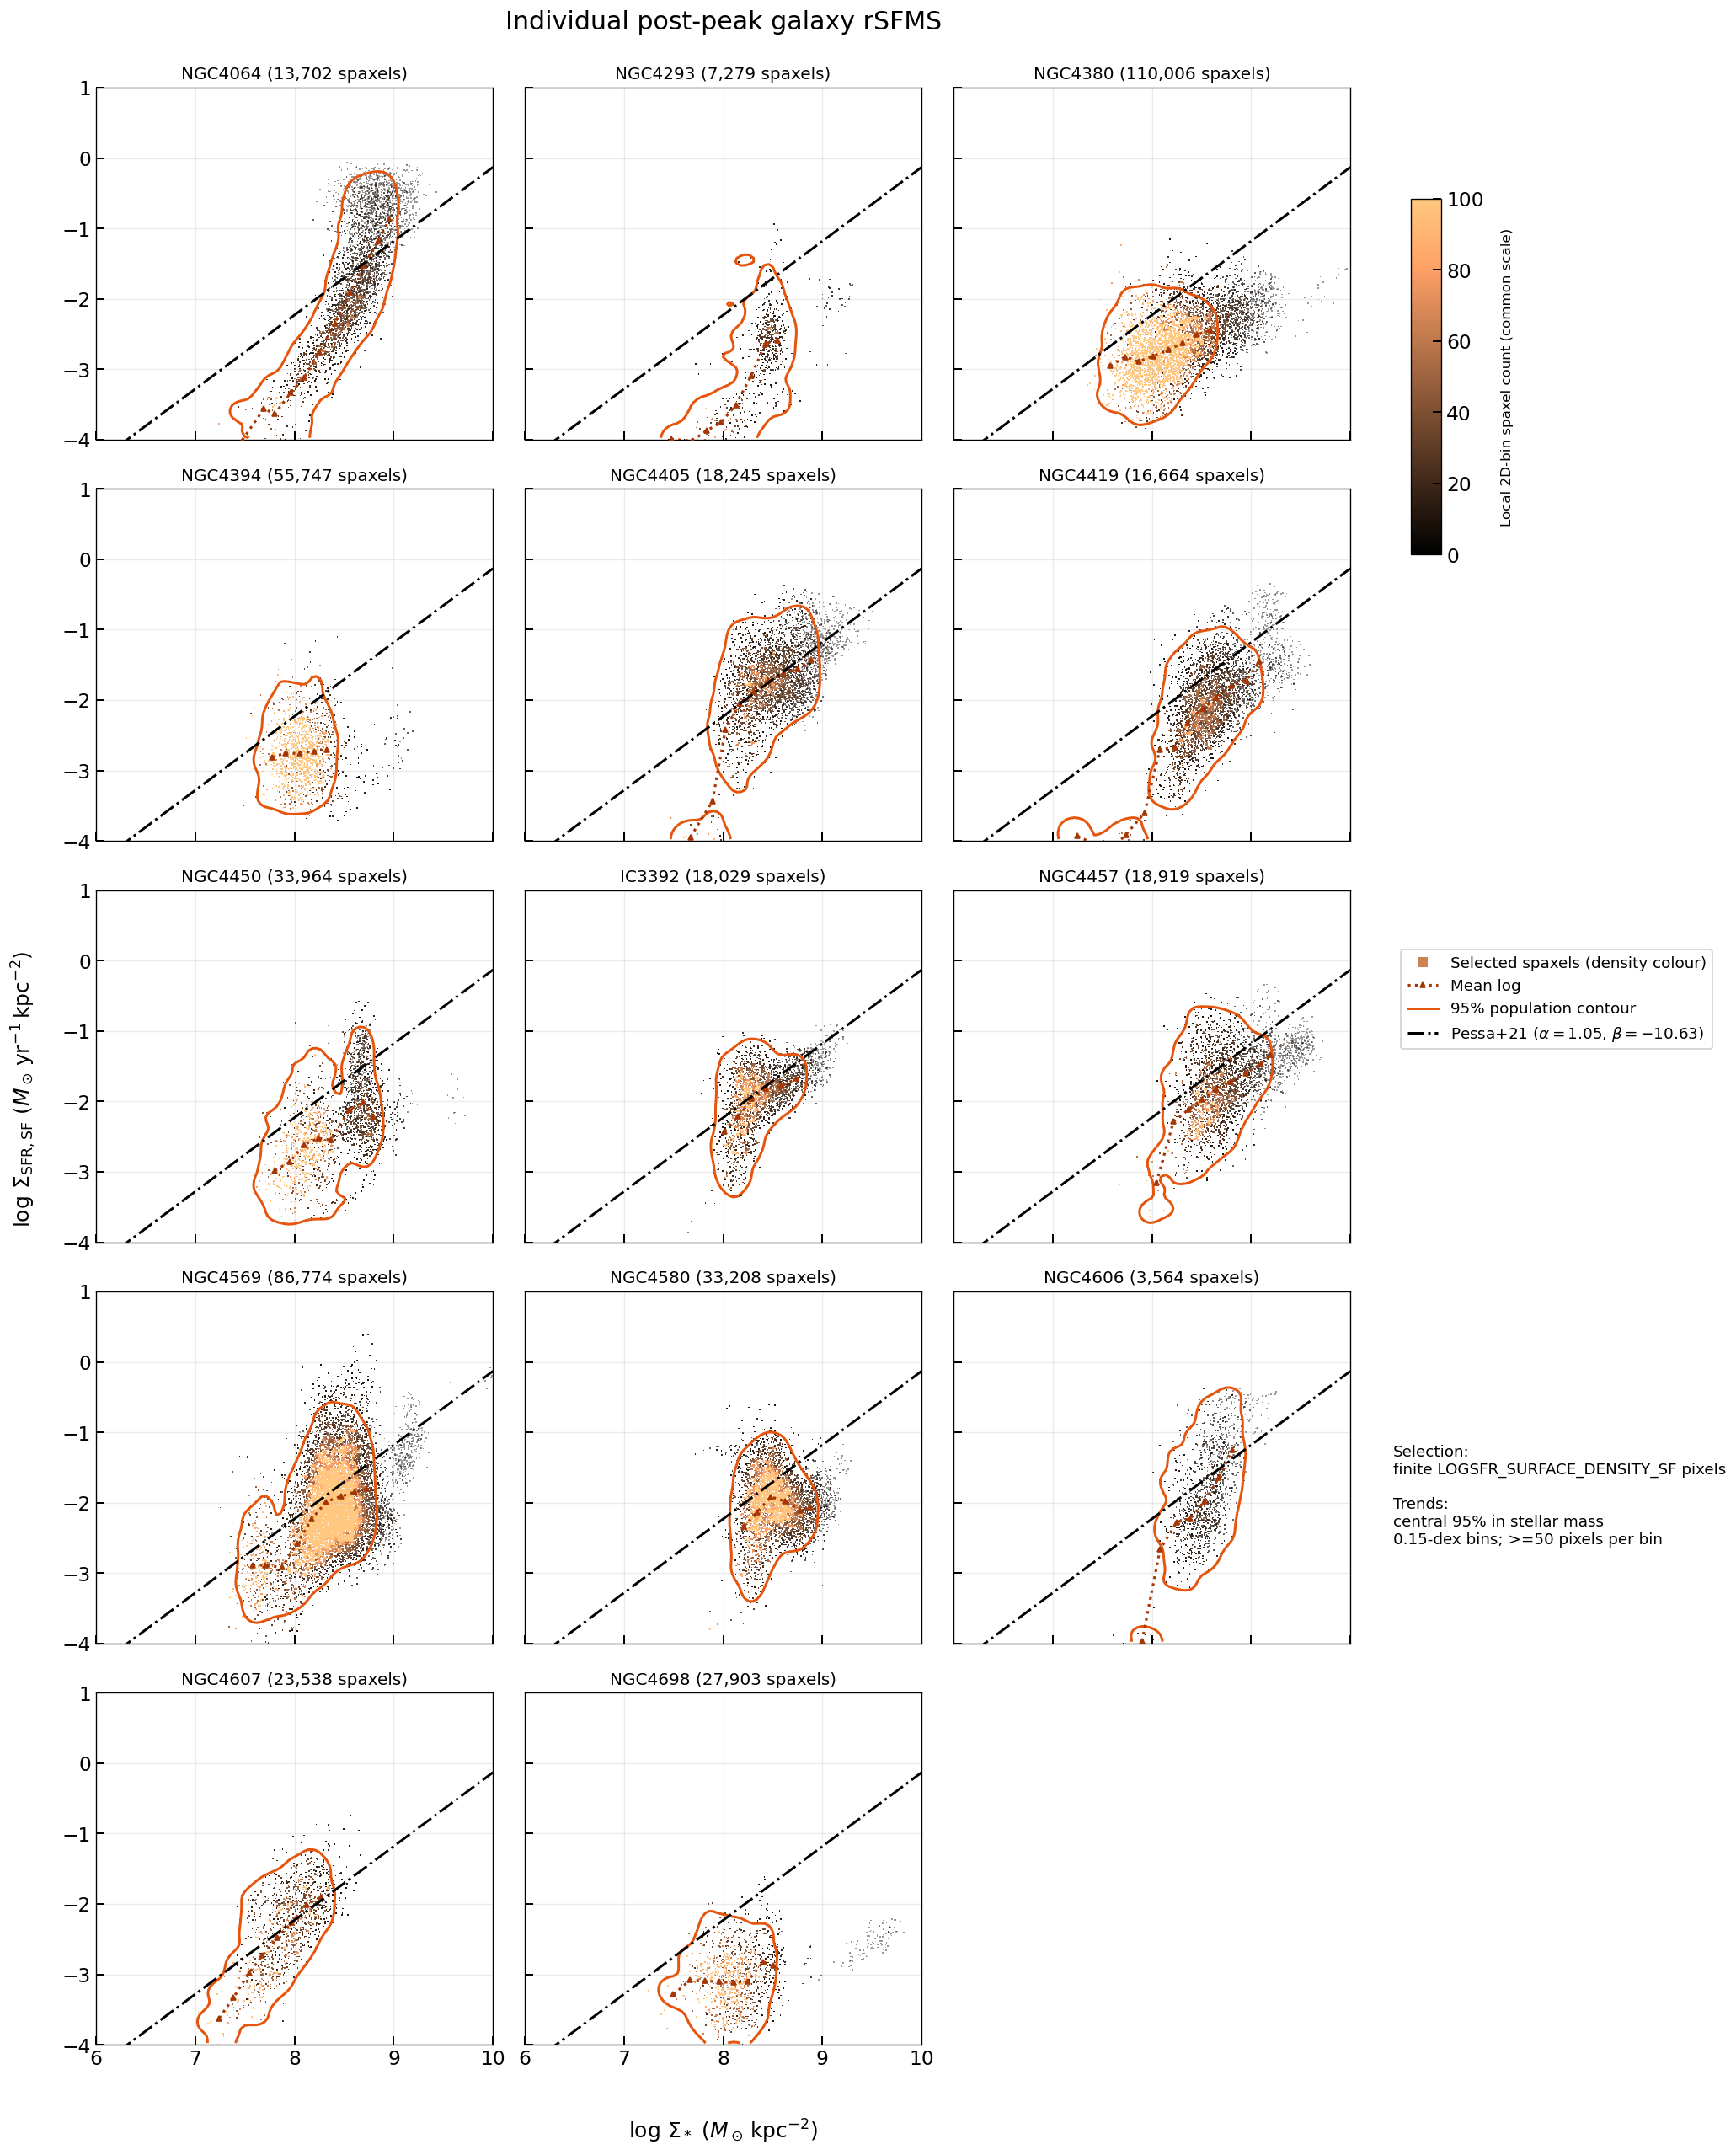

Individual post-peak grid summary:
  NGC4064: 13,702 spaxels, central-95% mass=7.430-8.992, valid bins=11
  NGC4293: 7,279 spaxels, central-95% mass=7.451-8.625, valid bins=8
  NGC4380: 110,006 spaxels, central-95% mass=7.491-8.657, valid bins=8
  NGC4394: 55,747 spaxels, central-95% mass=7.682-8.384, valid bins=5
  NGC4405: 18,245 spaxels, central-95% mass=7.634-8.938, valid bins=9
  NGC4419: 16,664 spaxels, central-95% mass=7.236-9.123, valid bins=13
  NGC4450: 33,964 spaxels, central-95% mass=7.717-8.822, valid bins=8
  IC3392: 18,029 spaxels, central-95% mass=7.918-8.814, valid bins=6
  NGC4457: 18,919 spaxels, central-95% mass=7.979-9.212, valid bins=9
  NGC4569: 86,774 spaxels, central-95% mass=7.494-8.760, valid bins=9
  NGC4580: 33,208 spaxels, central-95% mass=8.111-8.902, valid bins=6
  NGC4606: 3,564 spaxels, central-95% mass=7.856-8.889, valid bins=7
  NGC4607: 23,538 spaxels, central-95% mass=7.153-8.342, valid bins=8
  NGC4698: 27,903 spaxels, central-95% mass=7.434-8.520

In [25]:
# Five-by-three summary of all currently available post-peak galaxies.
from matplotlib.colors import Normalize

grid_galaxies = list(POST_PEAK_AVAILABLE_GALAXIES)
grid_data = {}
GRID_DENSITY_VMAX = 100.0

# Prepare every galaxy first so all panels can share one density normalization.
for galaxy in grid_galaxies:
    if rsfms_infall_class.get(galaxy) != RSFMS_STAGE:
        raise ValueError(f"{galaxy} is not a post-peak galaxy")

    maps = load_selected_rsfms_maps(galaxy)
    selected = selected_rsfms_mask(*maps)
    log_sigma_m, log_sigma_sfr = maps
    x = np.asarray(log_sigma_m[selected], dtype=float)
    y = np.asarray(log_sigma_sfr[selected], dtype=float)
    if x.size == 0:
        raise RuntimeError(f"{galaxy}: no finite SF spaxels")

    histogram, xedges, yedges = np.histogram2d(
        x,
        y,
        bins=100,
        range=[RSFMS_XRANGE, RSFMS_YRANGE],
    )
    x_index = np.clip(np.digitize(x, xedges) - 1, 0, histogram.shape[0] - 1)
    y_index = np.clip(np.digitize(y, yedges) - 1, 0, histogram.shape[1] - 1)
    density = histogram[x_index, y_index]

    (
        trend_x,
        mean_log,
        trend_counts,
        (trend_lo, trend_hi),
    ) = binned_rsfms_mean_trend(
        x,
        y,
        bin_width=RSFMS_BIN_WIDTH,
        min_pixels=RSFMS_MIN_PIXELS_PER_BIN,
    )
    grid_data[galaxy] = {
        "x": x,
        "y": y,
        "density": density,
        "trend_x": trend_x,
        "mean_log": mean_log,
        "trend_counts": trend_counts,
        "trend_limits": (trend_lo, trend_hi),
    }

# Cap the shared colour scale so moderate-density structure remains visible.
grid_density_norm = Normalize(vmin=0.0, vmax=GRID_DENSITY_VMAX, clip=True)
fig, grid_axes_2d = plt.subplots(
    5,
    3,
    figsize=(17, 22),
    sharex=True,
    sharey=True,
    constrained_layout=False,
)
grid_axes = grid_axes_2d.ravel()
fig.subplots_adjust(
    left=0.07,
    right=0.80,
    bottom=0.07,
    top=0.95,
    wspace=0.08,
    hspace=0.14,
)
x_pessa_grid = np.linspace(*RSFMS_XRANGE, 200)
y_pessa_grid = pessa_alpha * x_pessa_grid + pessa_intercept

for ax, galaxy in zip(grid_axes, grid_galaxies):
    data = grid_data[galaxy]
    ax.scatter(
        data["x"],
        data["y"],
        c=data["density"],
        norm=grid_density_norm,
        s=1,
        alpha=0.4,
        marker=",",
        cmap="copper",
        edgecolors="none",
        rasterized=True,
        zorder=1,
    )
    plot_stage_95_contour(
        ax,
        data["x"],
        data["y"],
        color=RSFMS_CONTOUR_COLOR,
        zorder=STAGE_CONTOUR_ZORDER,
    )
    ax.plot(
        data["trend_x"],
        data["mean_log"],
        color=RSFMS_MEAN_LOG_COLOR,
        linestyle=":",
        marker="^",
        markersize=3.3,
        linewidth=1.9,
        zorder=7.1,
    )
    ax.plot(
        x_pessa_grid,
        y_pessa_grid,
        color="black",
        linestyle="-.",
        linewidth=1.8,
        zorder=8.0,
    )
    ax.set(
        xlim=RSFMS_XRANGE,
        ylim=RSFMS_YRANGE,
        title=f"{galaxy} ({data['x'].size:,} spaxels)",
    )
    ax.grid(True, alpha=0.25)

# Hide the one unused position in the five-by-three grid.
for ax in grid_axes[len(grid_galaxies):]:
    ax.axis("off")

legend_handles = [
    Line2D(
        [0], [0], marker="s", color="none", markerfacecolor=plt.get_cmap("copper")(0.65),
        markeredgecolor="none", markersize=7, label="Selected spaxels (density colour)",
    ),
    Line2D(
        [0], [0], color=RSFMS_MEAN_LOG_COLOR, linestyle=":", marker="^",
        linewidth=1.9, markersize=4, label="Mean log",
    ),
    Line2D(
        [0], [0], color=RSFMS_CONTOUR_COLOR, linewidth=1.8,
        label="95% population contour",
    ),
    Line2D(
        [0], [0], color="black", linestyle="-.", linewidth=1.8,
        label=r"Pessa+21 ($\alpha=1.05$, $\beta=-10.63$)",
    ),
]
fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(0.825, 0.54),
    ncol=1,
    framealpha=0.9,
    fontsize=11,
)
fig.supxlabel(
    r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
    x=0.435,
    y=0.025,
    fontsize=15,
)
fig.supylabel(
    r"$\log\,\Sigma_{\mathrm{SFR,SF}} \ "
    r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$",
    x=0.02,
    fontsize=15,
)
fig.suptitle(
    "Individual post-peak galaxy rSFMS",
    x=0.435,
    y=0.985,
    fontsize=18,
)

density_mappable = mpl.cm.ScalarMappable(norm=grid_density_norm, cmap="copper")
density_mappable.set_array([])
density_colorbar_axis = fig.add_axes([0.835, 0.74, 0.018, 0.16])
grid_colorbar = fig.colorbar(
    density_mappable,
    cax=density_colorbar_axis,
    orientation="vertical",
)
grid_colorbar.set_label(
    "Local 2D-bin spaxel count (common scale)",
    rotation=90,
    labelpad=12,
)
fig.text(
    0.825,
    0.34,
    "Selection:\n"
    "finite LOGSFR_SURFACE_DENSITY_SF pixels\n\n"
    "Trends:\n"
    "central 95% in stellar mass\n"
    "0.15-dex bins; >=50 pixels per bin",
    ha="left",
    va="top",
    fontsize=11,
)

# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_post_peak_individual_grid.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_post_peak_individual_grid.pdf", bbox_inches="tight")
plt.show()

print("Individual post-peak grid summary:")
for galaxy in grid_galaxies:
    data = grid_data[galaxy]
    trend_lo, trend_hi = data["trend_limits"]
    valid_bins = int(
        np.count_nonzero(data["trend_counts"] >= RSFMS_MIN_PIXELS_PER_BIN)
    )
    print(
        f"  {galaxy}: {data['x'].size:,} spaxels, "
        f"central-95% mass={trend_lo:.3f}-{trend_hi:.3f}, "
        f"valid bins={valid_bins}"
    )
